# CNN for Image Classification on CIFAR-10

## Aim
To design, implement, train, and evaluate a Convolutional Neural Network (CNN) using TensorFlow/Keras for multi-class image classification on the CIFAR-10 dataset, and to study the effect of CNN hyperparameters, feature maps, and pooling strategies on model performance.

## Objectives
1. Understand fundamental CNN building blocks: convolution, activation, pooling, flattening, and fully connected layers.
2. Study how convolution kernels extract features such as edges, textures, and patterns.
3. Study the effect of hyperparameters: kernel size, stride, padding, number of filters, optimizer, batch size, epochs.
4. Visualize intermediate feature maps to understand hierarchical feature learning.
5. Compare pooling strategies (Max Pooling vs Average Pooling).
6. Analyze the number of trainable parameters in convolutional layers.
7. Train and evaluate a CNN on CIFAR-10 using accuracy, precision, recall, F1-score, confusion matrix, and classification report.

## Dataset
**CIFAR-10**: 60,000 32x32 color images in 10 classes (6000 images per class) — airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck. 50,000 training images and 10,000 test images.


## 1. Setup: Fonts and Imports

In [3]:
!wget -q -O "TimesNewRoman.ttf" "https://raw.githubusercontent.com/justrajdeep/fonts/master/Times%20New%20Roman.ttf"

import matplotlib
import matplotlib.font_manager as font_manager
import shutil as _shutil
_shutil.rmtree(matplotlib.get_cachedir(), ignore_errors=True)

font_manager.fontManager.addfont("TimesNewRoman.ttf")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow version: 2.20.0


## 2. Global Plot Formatting (600 DPI, Times New Roman, EPS export)

In [4]:
# Global Plot Formatting

plt.rcParams['savefig.dpi'] = 600
plt.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = 'Times New Roman'

plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

plt.rcParams['axes.labelsize'] = 15
plt.rcParams['axes.titlesize'] = 15

plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15

plt.rcParams['legend.fontsize'] = 15

sns.set_style("whitegrid")
sns.set_context("notebook")

label_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

title_style = {
    'fontsize': 15,
    'fontweight': 'bold',
    'fontname': 'Times New Roman'
}

legend_style = {
    'family': 'Times New Roman',
    'weight': 'bold',
    'size': 15
}

def format_axis_ticks(current_axis):

    for tick_label in (
        current_axis.get_xticklabels()
        + current_axis.get_yticklabels()
    ):
        tick_label.set_fontweight('bold')
        tick_label.set_fontname('Times New Roman')

def format_legend_text(current_legend):

    if current_legend is not None:

        for legend_entry in current_legend.get_texts():
            legend_entry.set_fontweight('bold')
            legend_entry.set_fontname('Times New Roman')

        legend_title = current_legend.get_title()
        if legend_title is not None:
            legend_title.set_fontweight('bold')
            legend_title.set_fontname('Times New Roman')


## 3. Load and Explore the CIFAR-10 Dataset

In [5]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training data shape :", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape      :", x_test.shape)
print("Test labels shape    :", y_test.shape)
print("Pixel value range    : [{}, {}]".format(x_train.min(), x_train.max()))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1681s 10us/step
Training data shape : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test data shape      : (10000, 32, 32, 3)
Test labels shape    : (10000, 1)
Pixel value range    : [0, 255]


### 3.1 Class Distribution

/tmp/ipykernel_1029/301048454.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  dist_axis = sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")


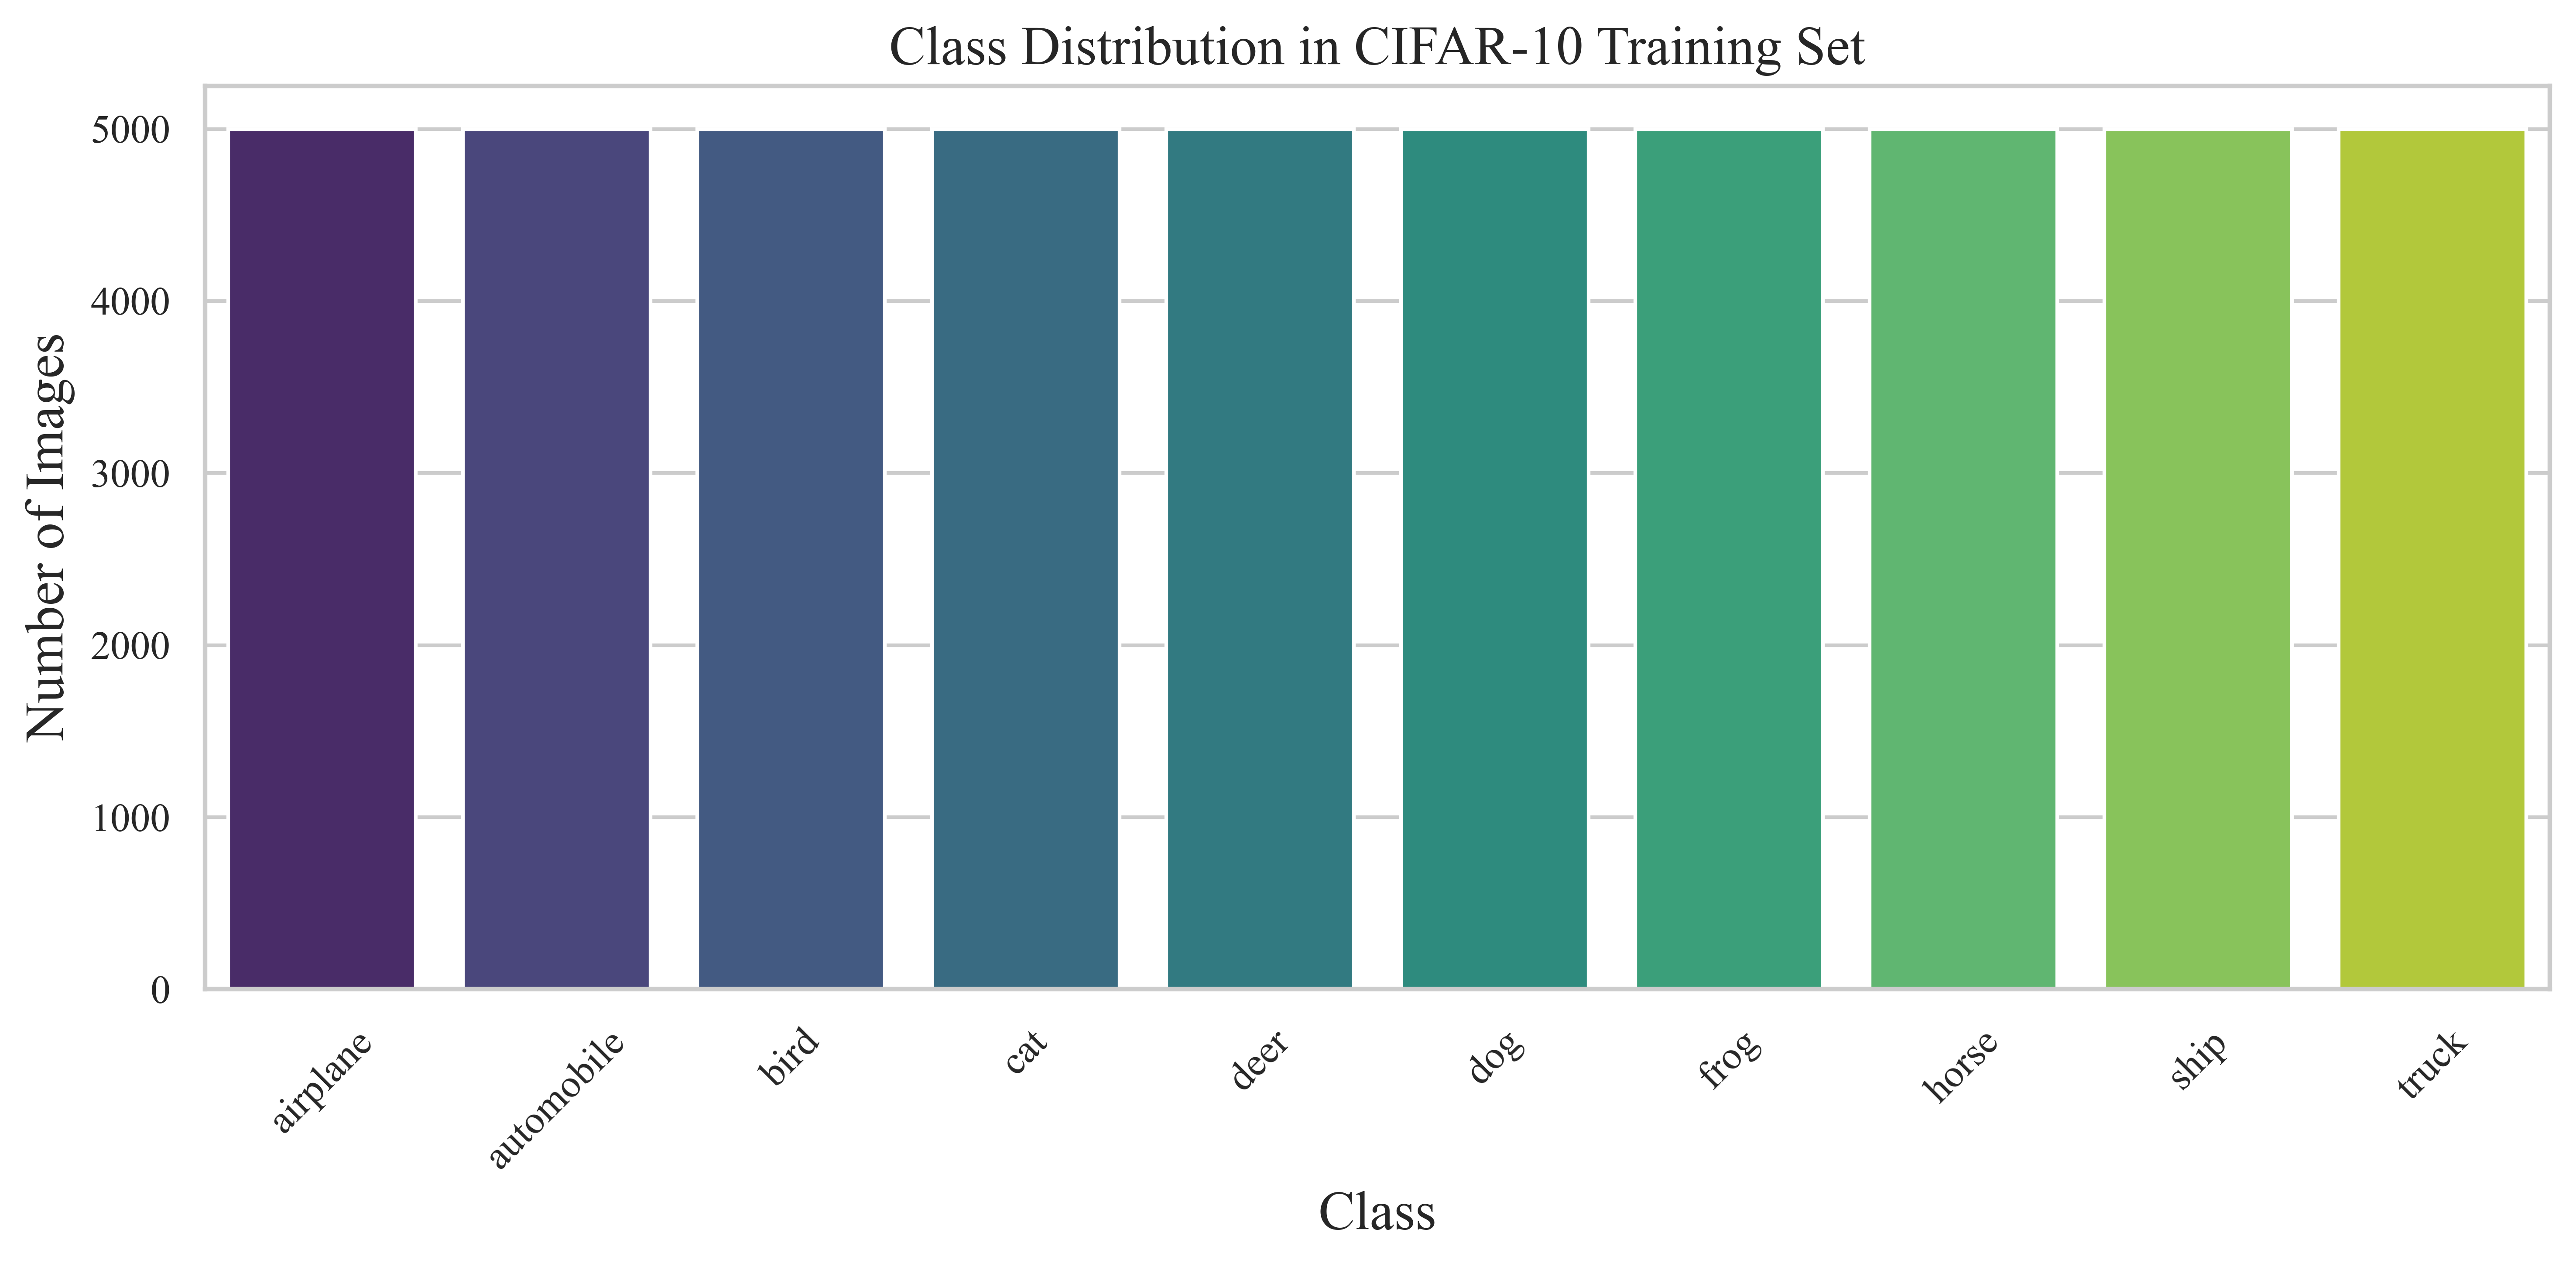

airplane    : 5000 images
automobile  : 5000 images
bird        : 5000 images
cat         : 5000 images
deer        : 5000 images
dog         : 5000 images
frog        : 5000 images
horse       : 5000 images
ship        : 5000 images
truck       : 5000 images


In [6]:
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
dist_axis = sns.barplot(x=[class_names[i] for i in unique], y=counts, palette="viridis")

dist_axis.set_title("Class Distribution in CIFAR-10 Training Set", **title_style)
dist_axis.set_xlabel("Class", **label_style)
dist_axis.set_ylabel("Number of Images", **label_style)
plt.xticks(rotation=45)

format_axis_ticks(dist_axis)

plt.tight_layout()

plt.savefig(
    "class_distribution.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

for i, c in zip(unique, counts):
    print(f"{class_names[i]:12s}: {c} images")


### 3.2 Sample Images from Each Class

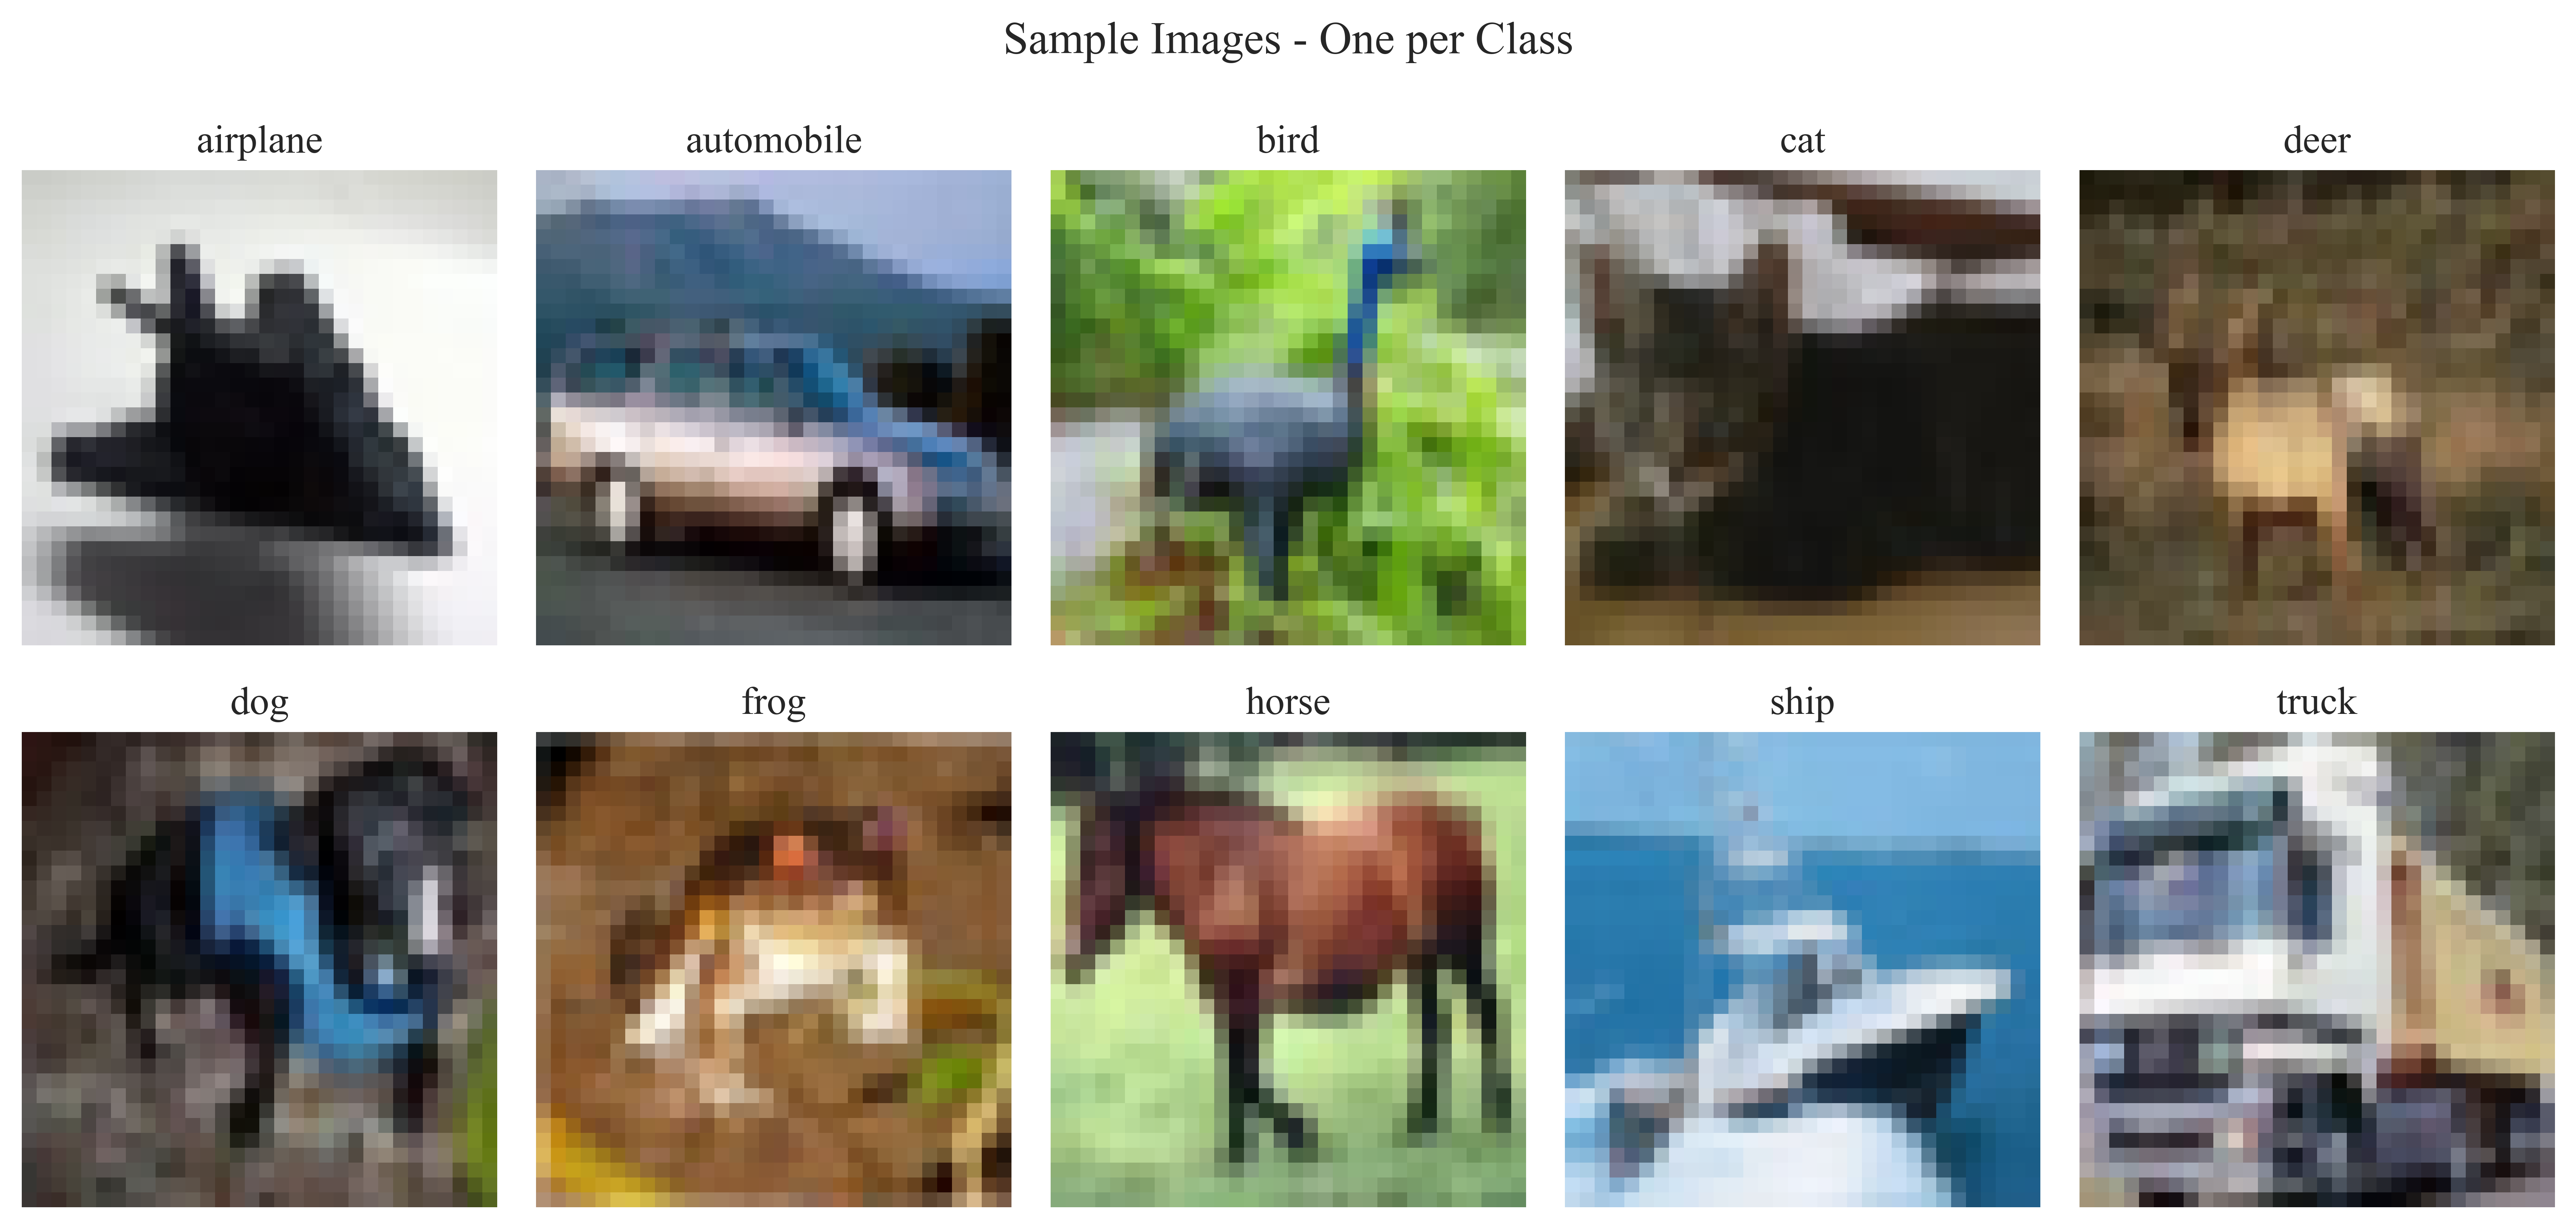

In [7]:
sample_fig, sample_axes = plt.subplots(2, 5, figsize=(12, 6))

for i in range(10):
    idx = np.where(y_train.flatten() == i)[0][0]
    current_axis = sample_axes.flatten()[i]
    current_axis.imshow(x_train[idx])
    current_axis.set_title(class_names[i], fontsize=13, fontweight='bold', fontname='Times New Roman')
    current_axis.axis('off')

sample_fig.suptitle("Sample Images - One per Class", fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()

plt.savefig(
    "sample_images.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 4. Data Preprocessing

- Normalize pixel values to the range [0, 1].
- One-hot encode the class labels for multi-class classification.
- Split a validation set from the training data.


In [8]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

# Create a validation split
val_size = 5000
x_val = x_train[:val_size]
y_val_cat = y_train_cat[:val_size]
x_train_final = x_train[val_size:]
y_train_final = y_train_cat[val_size:]

print("Final training set :", x_train_final.shape)
print("Validation set     :", x_val.shape)
print("Test set            :", x_test.shape)


Final training set : (45000, 32, 32, 3)
Validation set     : (5000, 32, 32, 3)
Test set            : (10000, 32, 32, 3)


## 5. CNN Building Blocks — Conceptual Overview

| Layer | Purpose |
|---|---|
| **Convolutional Layer** | Applies learnable kernels/filters that slide over the image to extract local features such as edges, textures, and patterns. Key hyperparameters: number of filters, kernel size, stride, padding. |
| **Activation Function (ReLU)** | Introduces non-linearity, allowing the network to learn complex patterns. |
| **Pooling Layer** | Downsamples feature maps (Max/Average Pooling), reducing spatial dimensions and computation while retaining important features and providing translation invariance. |
| **Batch Normalization** | Stabilizes and accelerates training by normalizing layer activations. |
| **Flatten Layer** | Converts 2D feature maps into a 1D vector for the fully connected layers. |
| **Fully Connected (Dense) Layer** | Combines extracted features to perform final classification. |
| **Dropout** | Regularization technique to reduce overfitting by randomly deactivating neurons during training. |

### Effect of Key Hyperparameters
- **Kernel size**: Larger kernels capture broader spatial context but increase parameters and computation; smaller kernels (e.g., 3x3) capture fine local detail and are computationally efficient.
- **Stride**: Larger stride reduces the output feature map size faster and reduces computation, but may skip fine detail.
- **Padding**: `'same'` padding preserves spatial dimensions; `'valid'` padding shrinks the feature map after every convolution.
- **Number of filters**: More filters allow the network to learn a richer set of features but increase the number of trainable parameters.
- **Optimizer**: Adam typically converges faster than plain SGD; RMSprop and SGD with momentum are common alternatives.
- **Batch size**: Smaller batches give noisier but often better-generalizing updates; larger batches are more computationally efficient per step but need more memory.
- **Epochs**: Too few epochs underfit; too many can overfit without regularization/early stopping.


## 6. CNN Architecture Design

We build a CNN with three convolutional blocks (Conv2D + BatchNorm + ReLU + MaxPooling), followed by flattening and fully connected layers with dropout for regularization. The model is built using the Keras **Functional API** (an explicit `Input` layer) so that intermediate layer outputs can be reliably extracted later for feature map visualization.


In [9]:
def build_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape, name='input_layer')

    # Block 1
    x = layers.Conv2D(32, kernel_size=(3, 3), strides=(1, 1),
                       padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool1')(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv3')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv4')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool2')(x)
    x = layers.Dropout(0.3)(x)

    # Block 3
    x = layers.Conv2D(128, kernel_size=(3, 3), padding='same',
                       activation='relu', name='conv5')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name='pool3')(x)
    x = layers.Dropout(0.4)(x)

    # Fully Connected Layers
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dense(256, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="CIFAR10_CNN")
    return model

model = build_cnn()
model.summary()


Model: "CIFAR10_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,57

 Total params: 668,842 (2.55 MB)

 Trainable params: 667,690 (2.55 MB)

 Non-trainable params: 1,152 (4.50 KB)

### 6.1 Analyzing Trainable Parameters of Convolutional Layers

In [10]:
print(f"{'Layer':15s} {'Output Shape':20s} {'Params':>12s}")
print("-" * 50)
total_conv_params = 0
for layer in model.layers:
    if 'conv' in layer.name:
        params = layer.count_params()
        total_conv_params += params
        print(f"{layer.name:15s} {str(tuple(layer.output.shape)):20s} {params:12,d}")

print("-" * 50)
print(f"Total Convolutional Layer Parameters: {total_conv_params:,d}")
print(f"Total Model Parameters              : {model.count_params():,d}")

# Manual verification for conv1: (kernel_h * kernel_w * in_channels + 1) * num_filters
kh, kw, in_ch, filters = 3, 3, 3, 32
manual_params = (kh * kw * in_ch + 1) * filters
print(f"\nManual check for 'conv1': (3*3*3 + 1) * 32 = {manual_params}")


Layer           Output Shape               Params
--------------------------------------------------
conv1           (None, 32, 32, 32)            896
conv2           (None, 32, 32, 32)          9,248
conv3           (None, 16, 16, 64)         18,496
conv4           (None, 16, 16, 64)         36,928
conv5           (None, 8, 8, 128)          73,856
--------------------------------------------------
Total Convolutional Layer Parameters: 139,424
Total Model Parameters              : 668,842

Manual check for 'conv1': (3*3*3 + 1) * 32 = 896


## 7. Compile the Model

We use the **Adam** optimizer, **categorical cross-entropy** loss (suitable for multi-class, one-hot encoded labels), and track **accuracy** as the metric.


In [11]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])


## 8. Train the CNN

Key hyperparameters used: `batch_size=64`, `epochs=20`. Data augmentation is applied to improve generalization.


In [12]:
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train_final)

BATCH_SIZE = 64
EPOCHS = 30

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=8, restore_best_weights=True
)

lr_schedule = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

history = model.fit(
    datagen.flow(x_train_final, y_train_final, batch_size=BATCH_SIZE),
    validation_data=(x_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=[early_stop, lr_schedule],
    verbose=1
)


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - accuracy: 0.3913 - loss: 1.8065 - val_accuracy: 0.5130 - val_loss: 1.3680 - learning_rate: 0.0010
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5328 - loss: 1.2990 - val_accuracy: 0.5944 - val_loss: 1.1270 - learning_rate: 0.0010
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.5916 - loss: 1.1410 - val_accuracy: 0.6036 - val_loss: 1.1228 - learning_rate: 0.0010
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6345 - loss: 1.0324 - val_accuracy: 0.6802 - val_loss: 0.9304 - learning_rate: 0.0010
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.6612 - loss: 0.9650 - val_accuracy: 0.7166 - val_loss: 0.8103 - learning_rate: 0.0010
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6802 - loss: 0.9122 - val_accuracy: 0.7050 - val_loss: 0.8440 - learning_rate: 0.0010
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.6936 - l

## 9. Training and Validation Accuracy/Loss Curves

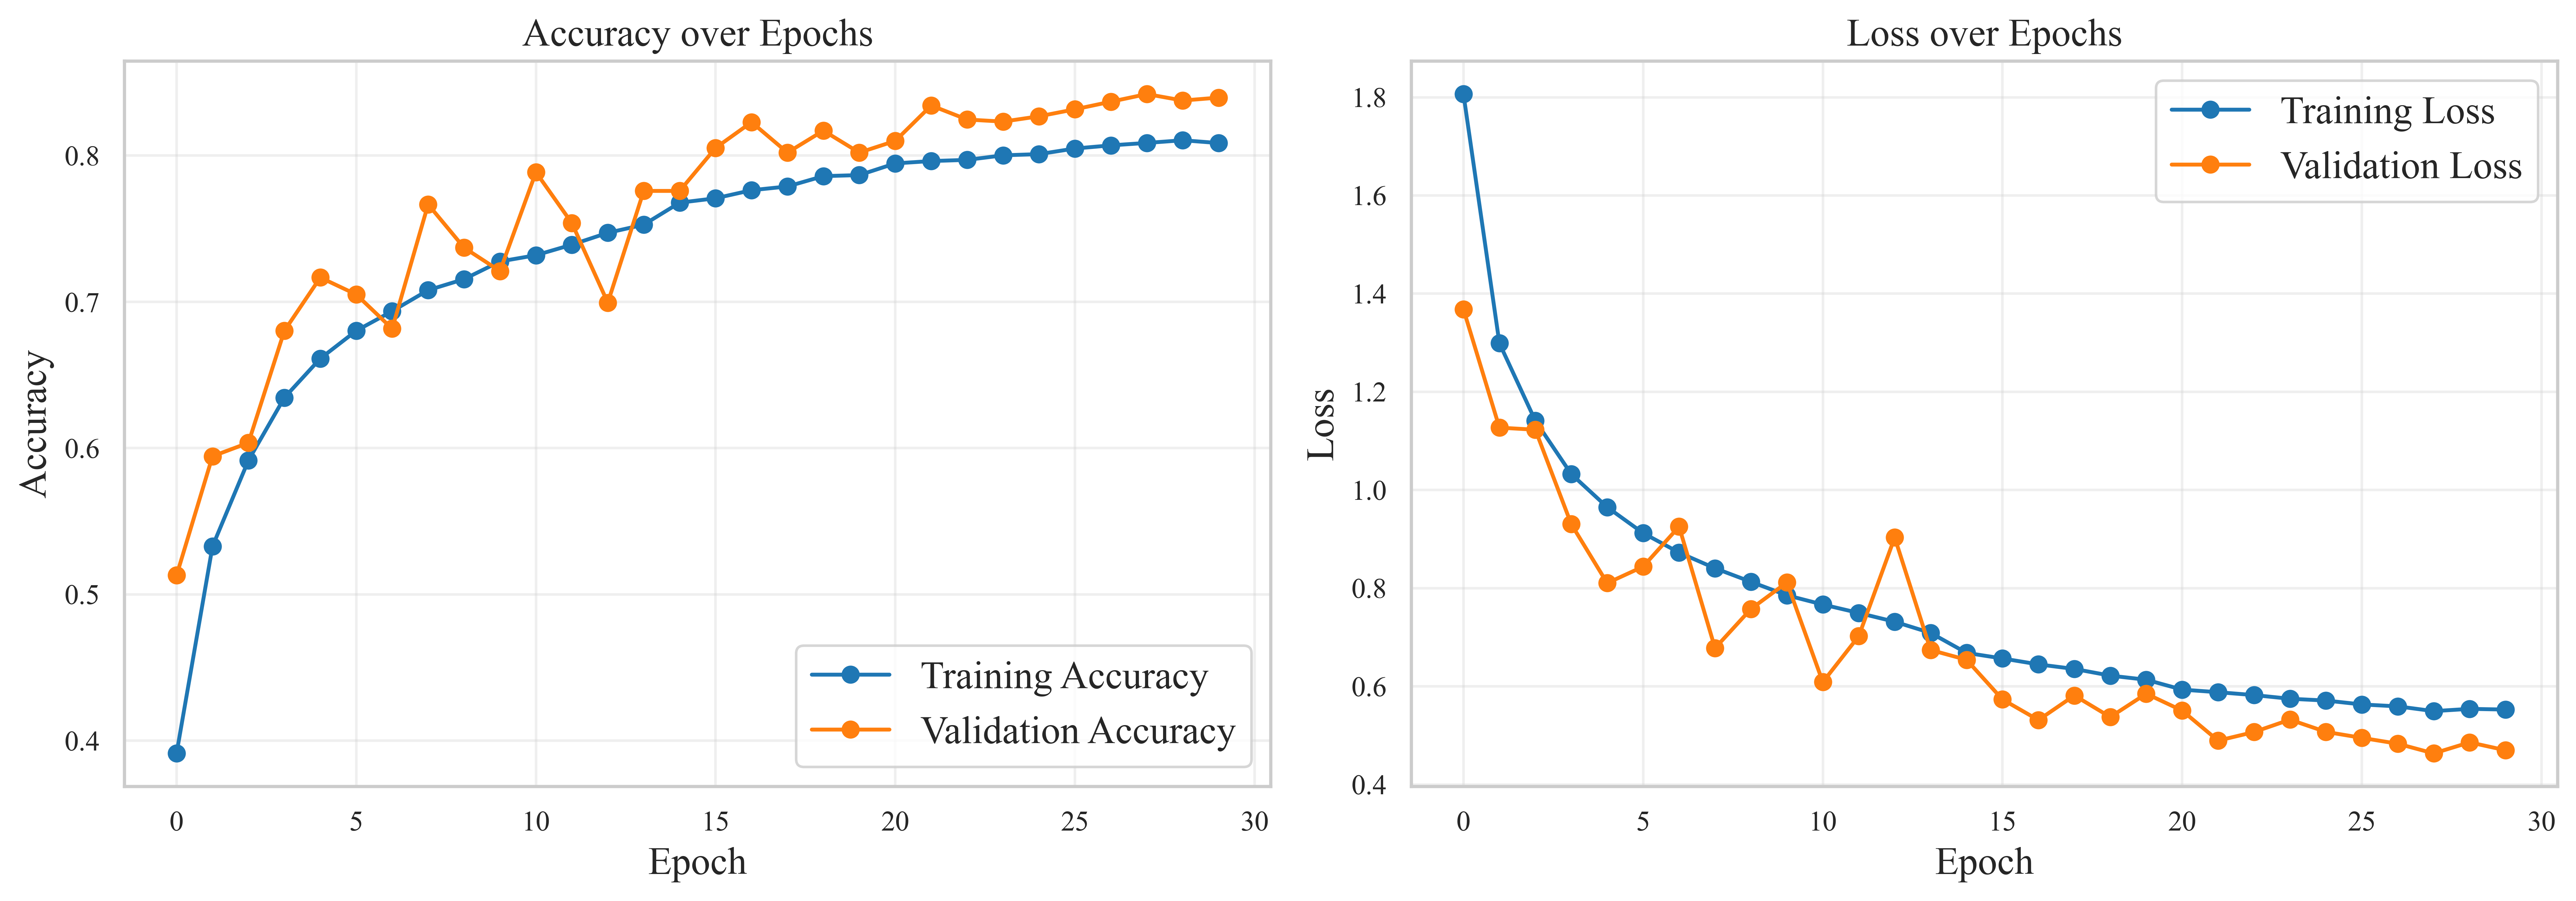

In [13]:
curve_fig, curve_axes = plt.subplots(1, 2, figsize=(14, 5))

acc_axis = curve_axes[0]
acc_axis.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
acc_axis.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
acc_axis.set_title('Accuracy over Epochs', **title_style)
acc_axis.set_xlabel('Epoch', **label_style)
acc_axis.set_ylabel('Accuracy', **label_style)
acc_legend = acc_axis.legend(prop=legend_style)
format_axis_ticks(acc_axis)
format_legend_text(acc_legend)
acc_axis.grid(alpha=0.3)

loss_axis = curve_axes[1]
loss_axis.plot(history.history['loss'], label='Training Loss', marker='o')
loss_axis.plot(history.history['val_loss'], label='Validation Loss', marker='o')
loss_axis.set_title('Loss over Epochs', **title_style)
loss_axis.set_xlabel('Epoch', **label_style)
loss_axis.set_ylabel('Loss', **label_style)
loss_legend = loss_axis.legend(prop=legend_style)
format_axis_ticks(loss_axis)
format_legend_text(loss_legend)
loss_axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "training_curves.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 10. Model Evaluation on Test Set

In [14]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()


Test Loss    : 0.5095
Test Accuracy: 0.8257


### 10.1 Precision, Recall, F1-Score

In [15]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


Accuracy : 0.8257
Precision: 0.8341
Recall   : 0.8257
F1-Score : 0.8235


### 10.2 Classification Report

In [16]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

    airplane       0.83      0.87      0.85      1000
  automobile       0.91      0.95      0.93      1000
        bird       0.86      0.69      0.77      1000
         cat       0.78      0.61      0.68      1000
        deer       0.79      0.82      0.80      1000
         dog       0.85      0.66      0.75      1000
        frog       0.65      0.96      0.78      1000
       horse       0.88      0.85      0.87      1000
        ship       0.92      0.92      0.92      1000
       truck       0.87      0.92      0.89      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.82     10000
weighted avg       0.83      0.83      0.82     10000



### 10.3 Confusion Matrix

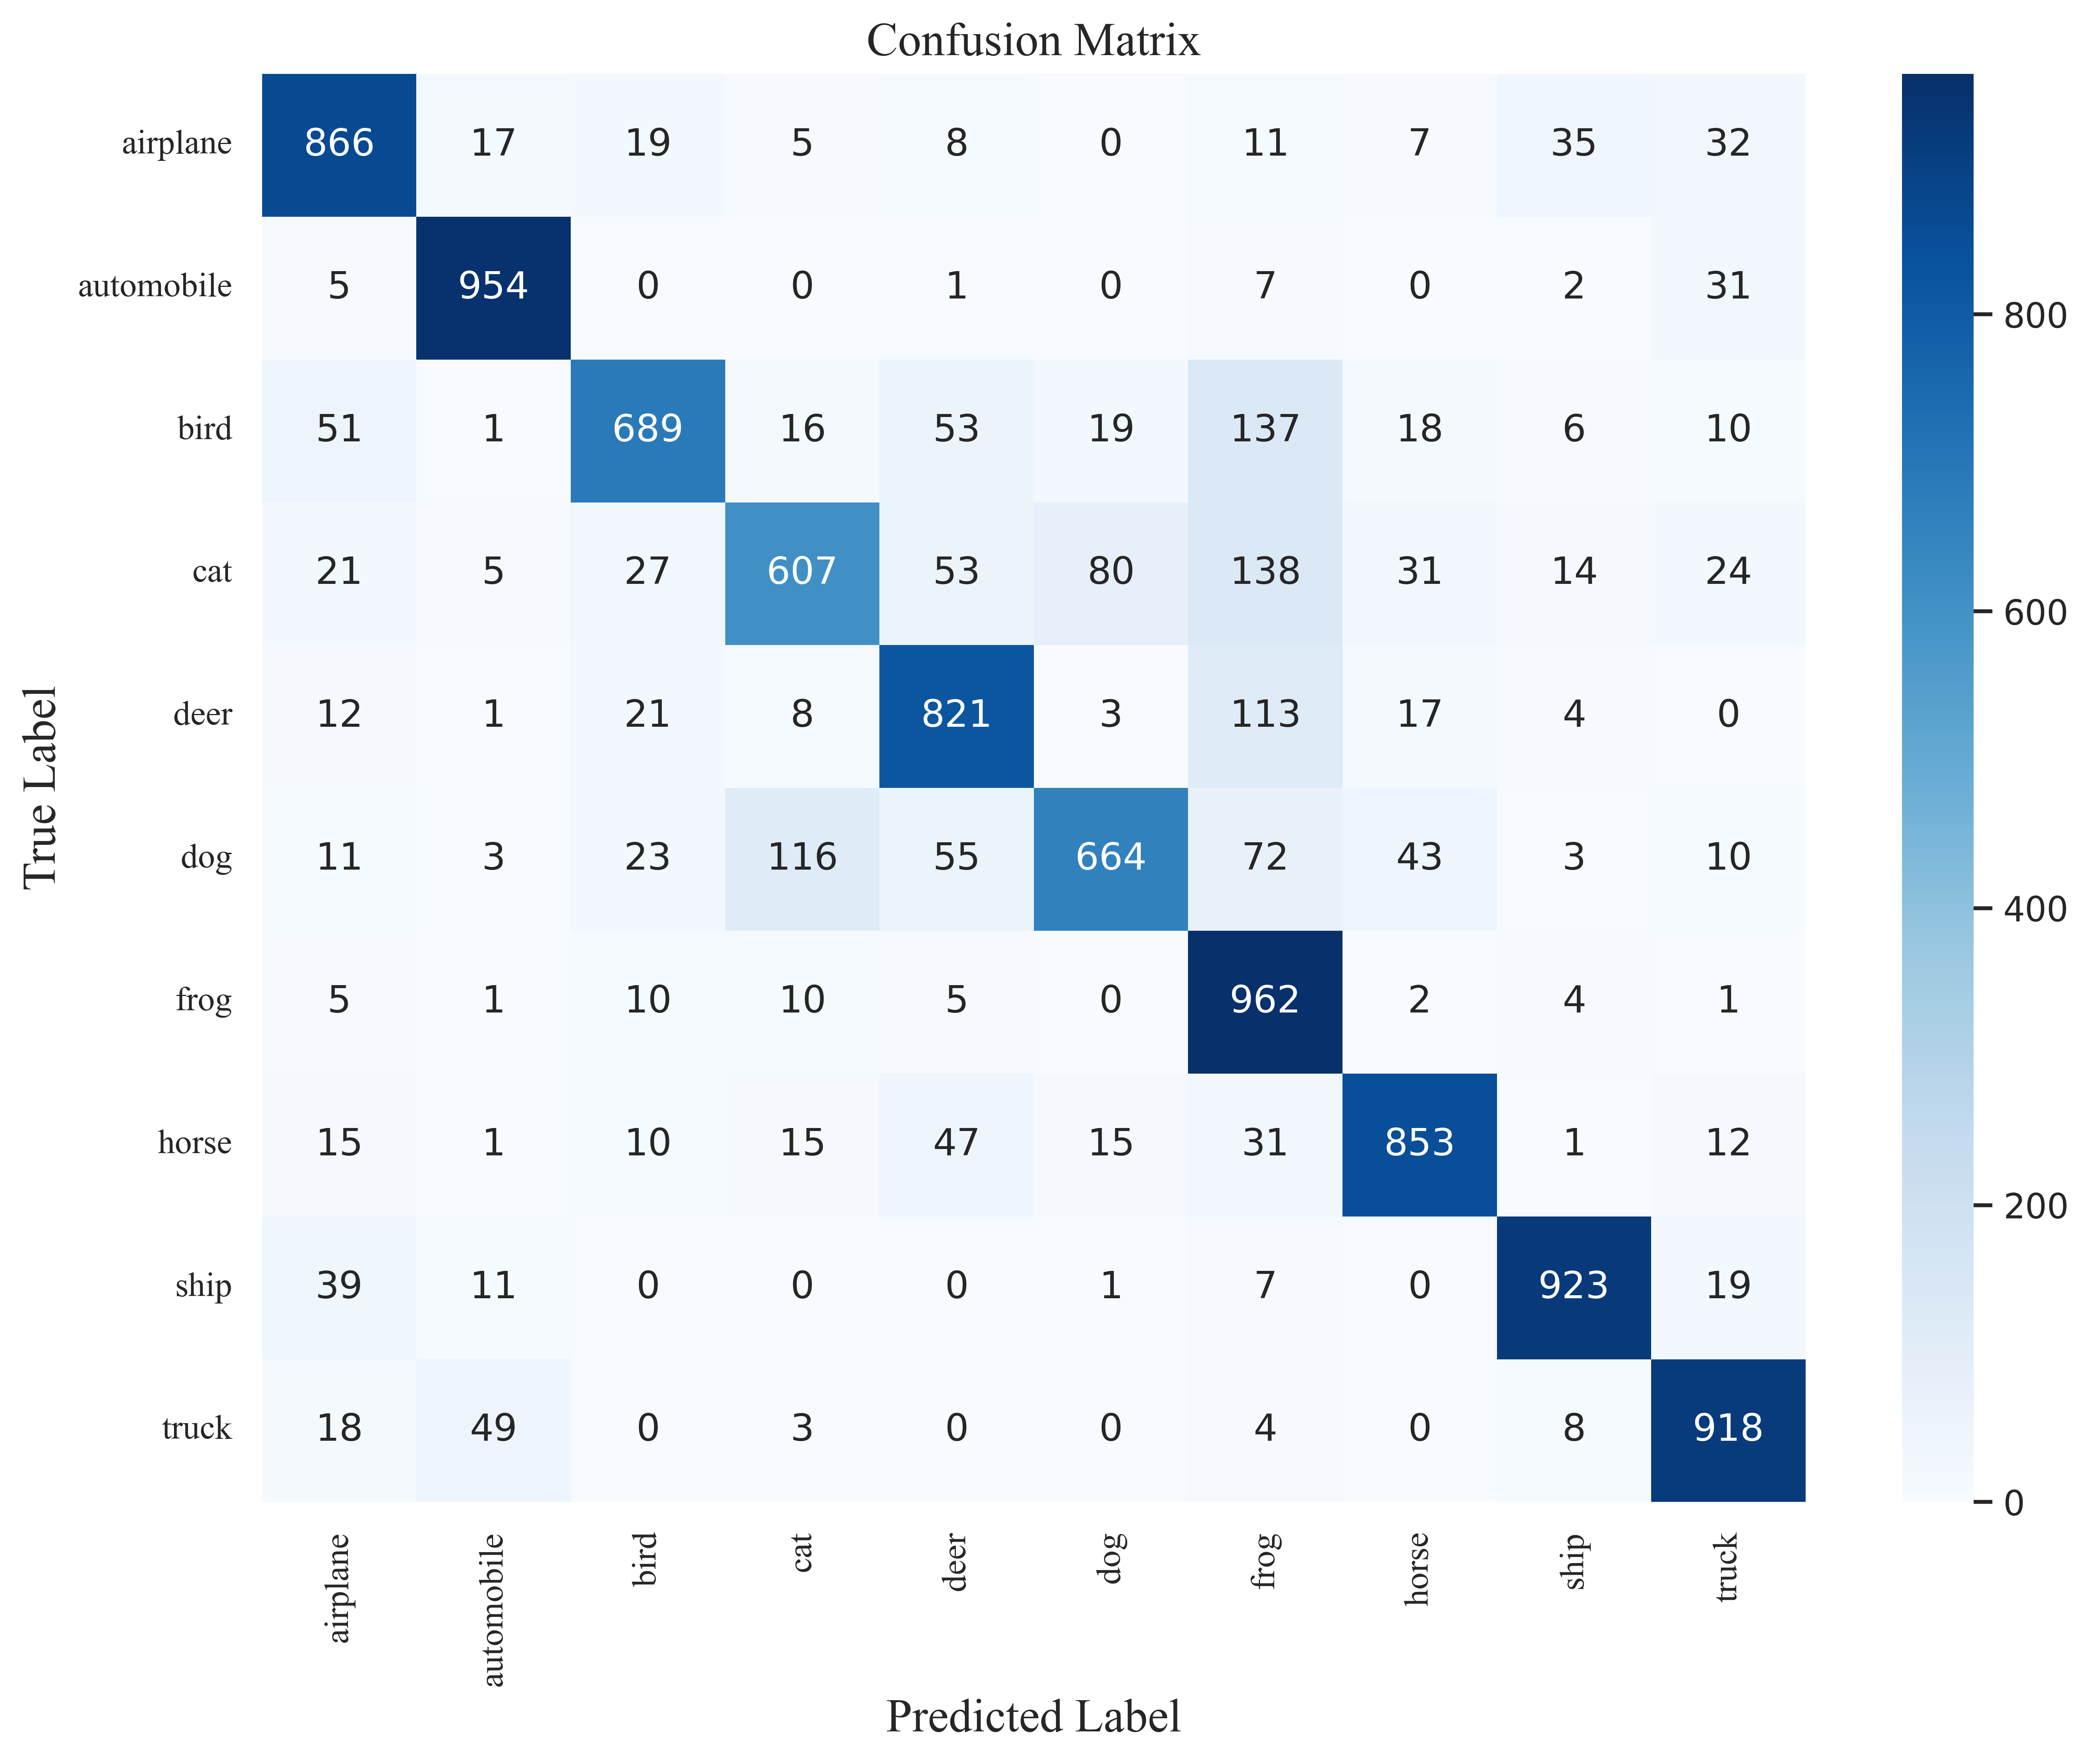

In [17]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

cm_axis = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                       xticklabels=class_names, yticklabels=class_names)

cm_axis.set_title('Confusion Matrix', **title_style)
cm_axis.set_xlabel('Predicted Label', **label_style)
cm_axis.set_ylabel('True Label', **label_style)

format_axis_ticks(cm_axis)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


### 10.4 Sample Predictions

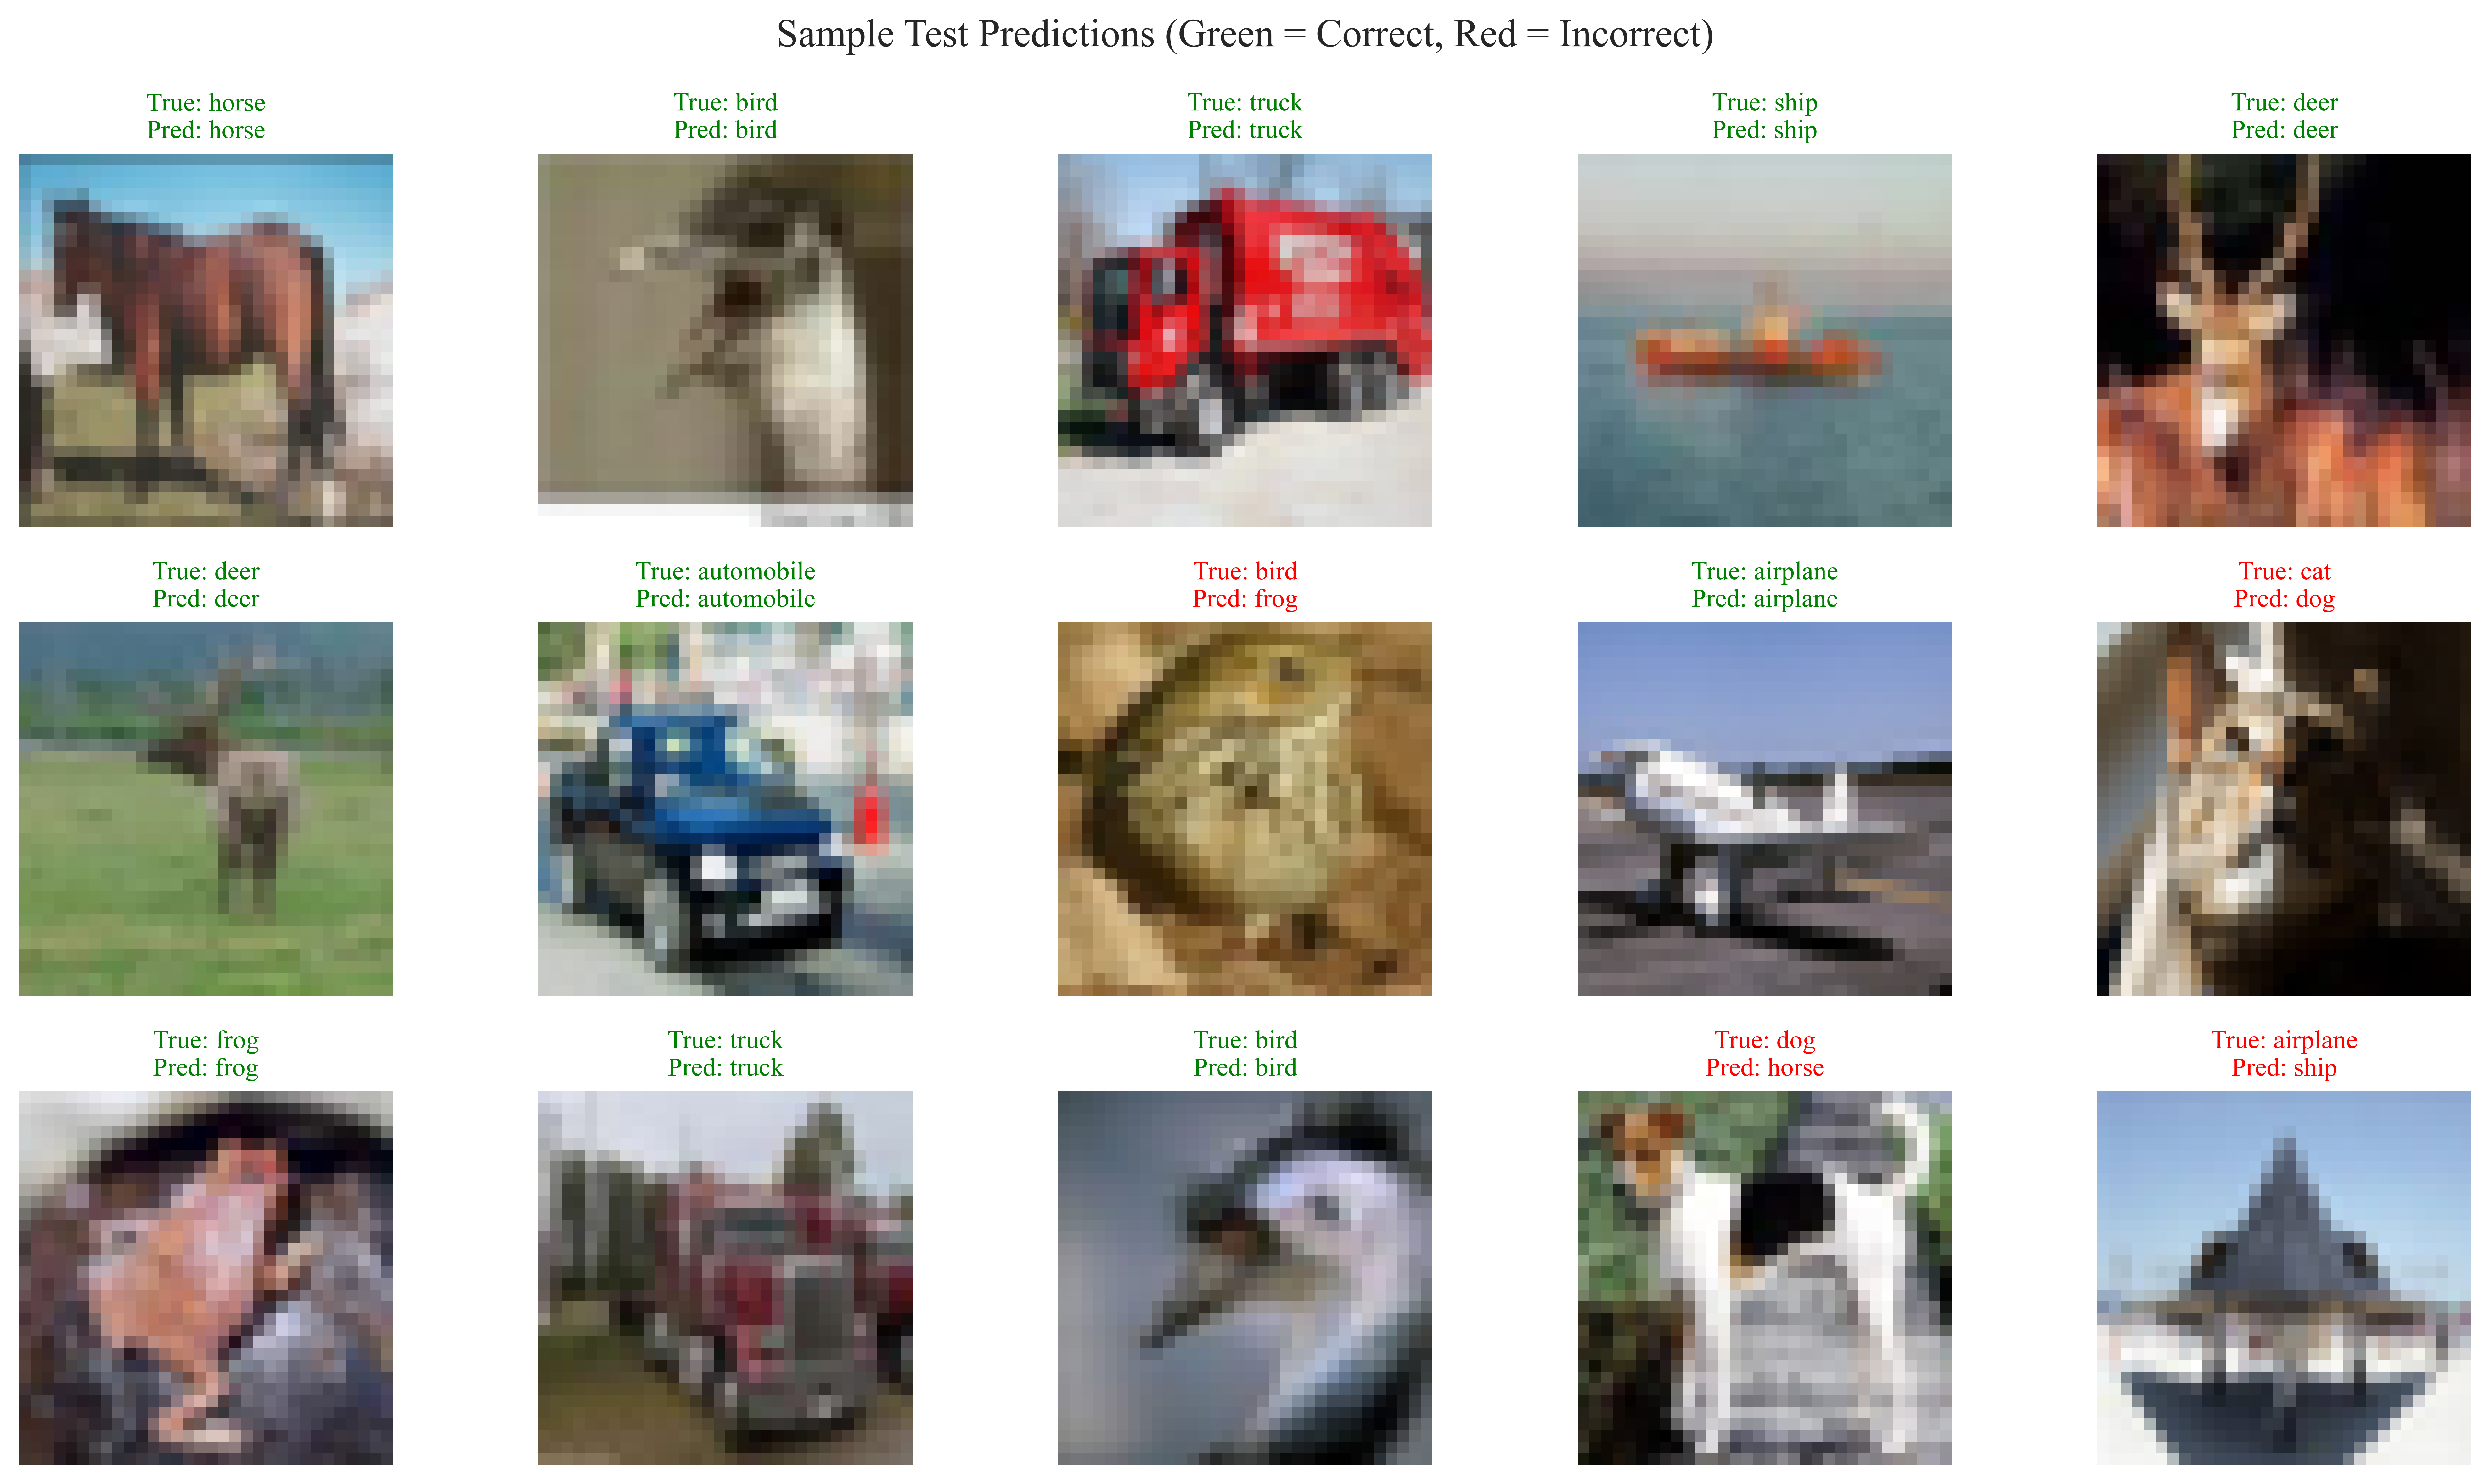

In [18]:
pred_fig, pred_axes = plt.subplots(3, 5, figsize=(14, 8))
indices = np.random.choice(len(x_test), 15, replace=False)

for i, idx in enumerate(indices):
    current_axis = pred_axes.flatten()[i]
    current_axis.imshow(x_test[idx])
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if true_label == pred_label else 'red'
    current_axis.set_title(f"True: {true_label}\nPred: {pred_label}",
                            color=color, fontsize=10, fontweight='bold', fontname='Times New Roman')
    current_axis.axis('off')

pred_fig.suptitle("Sample Test Predictions (Green = Correct, Red = Incorrect)",
                   fontsize=15, fontweight='bold', fontname='Times New Roman')
plt.tight_layout()

plt.savefig(
    "sample_predictions.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 11. Visualizing Intermediate Feature Maps

Extract outputs from the intermediate convolutional layers to observe how the CNN progressively learns hierarchical representations — early layers capture edges/textures, deeper layers capture more abstract/complex patterns.


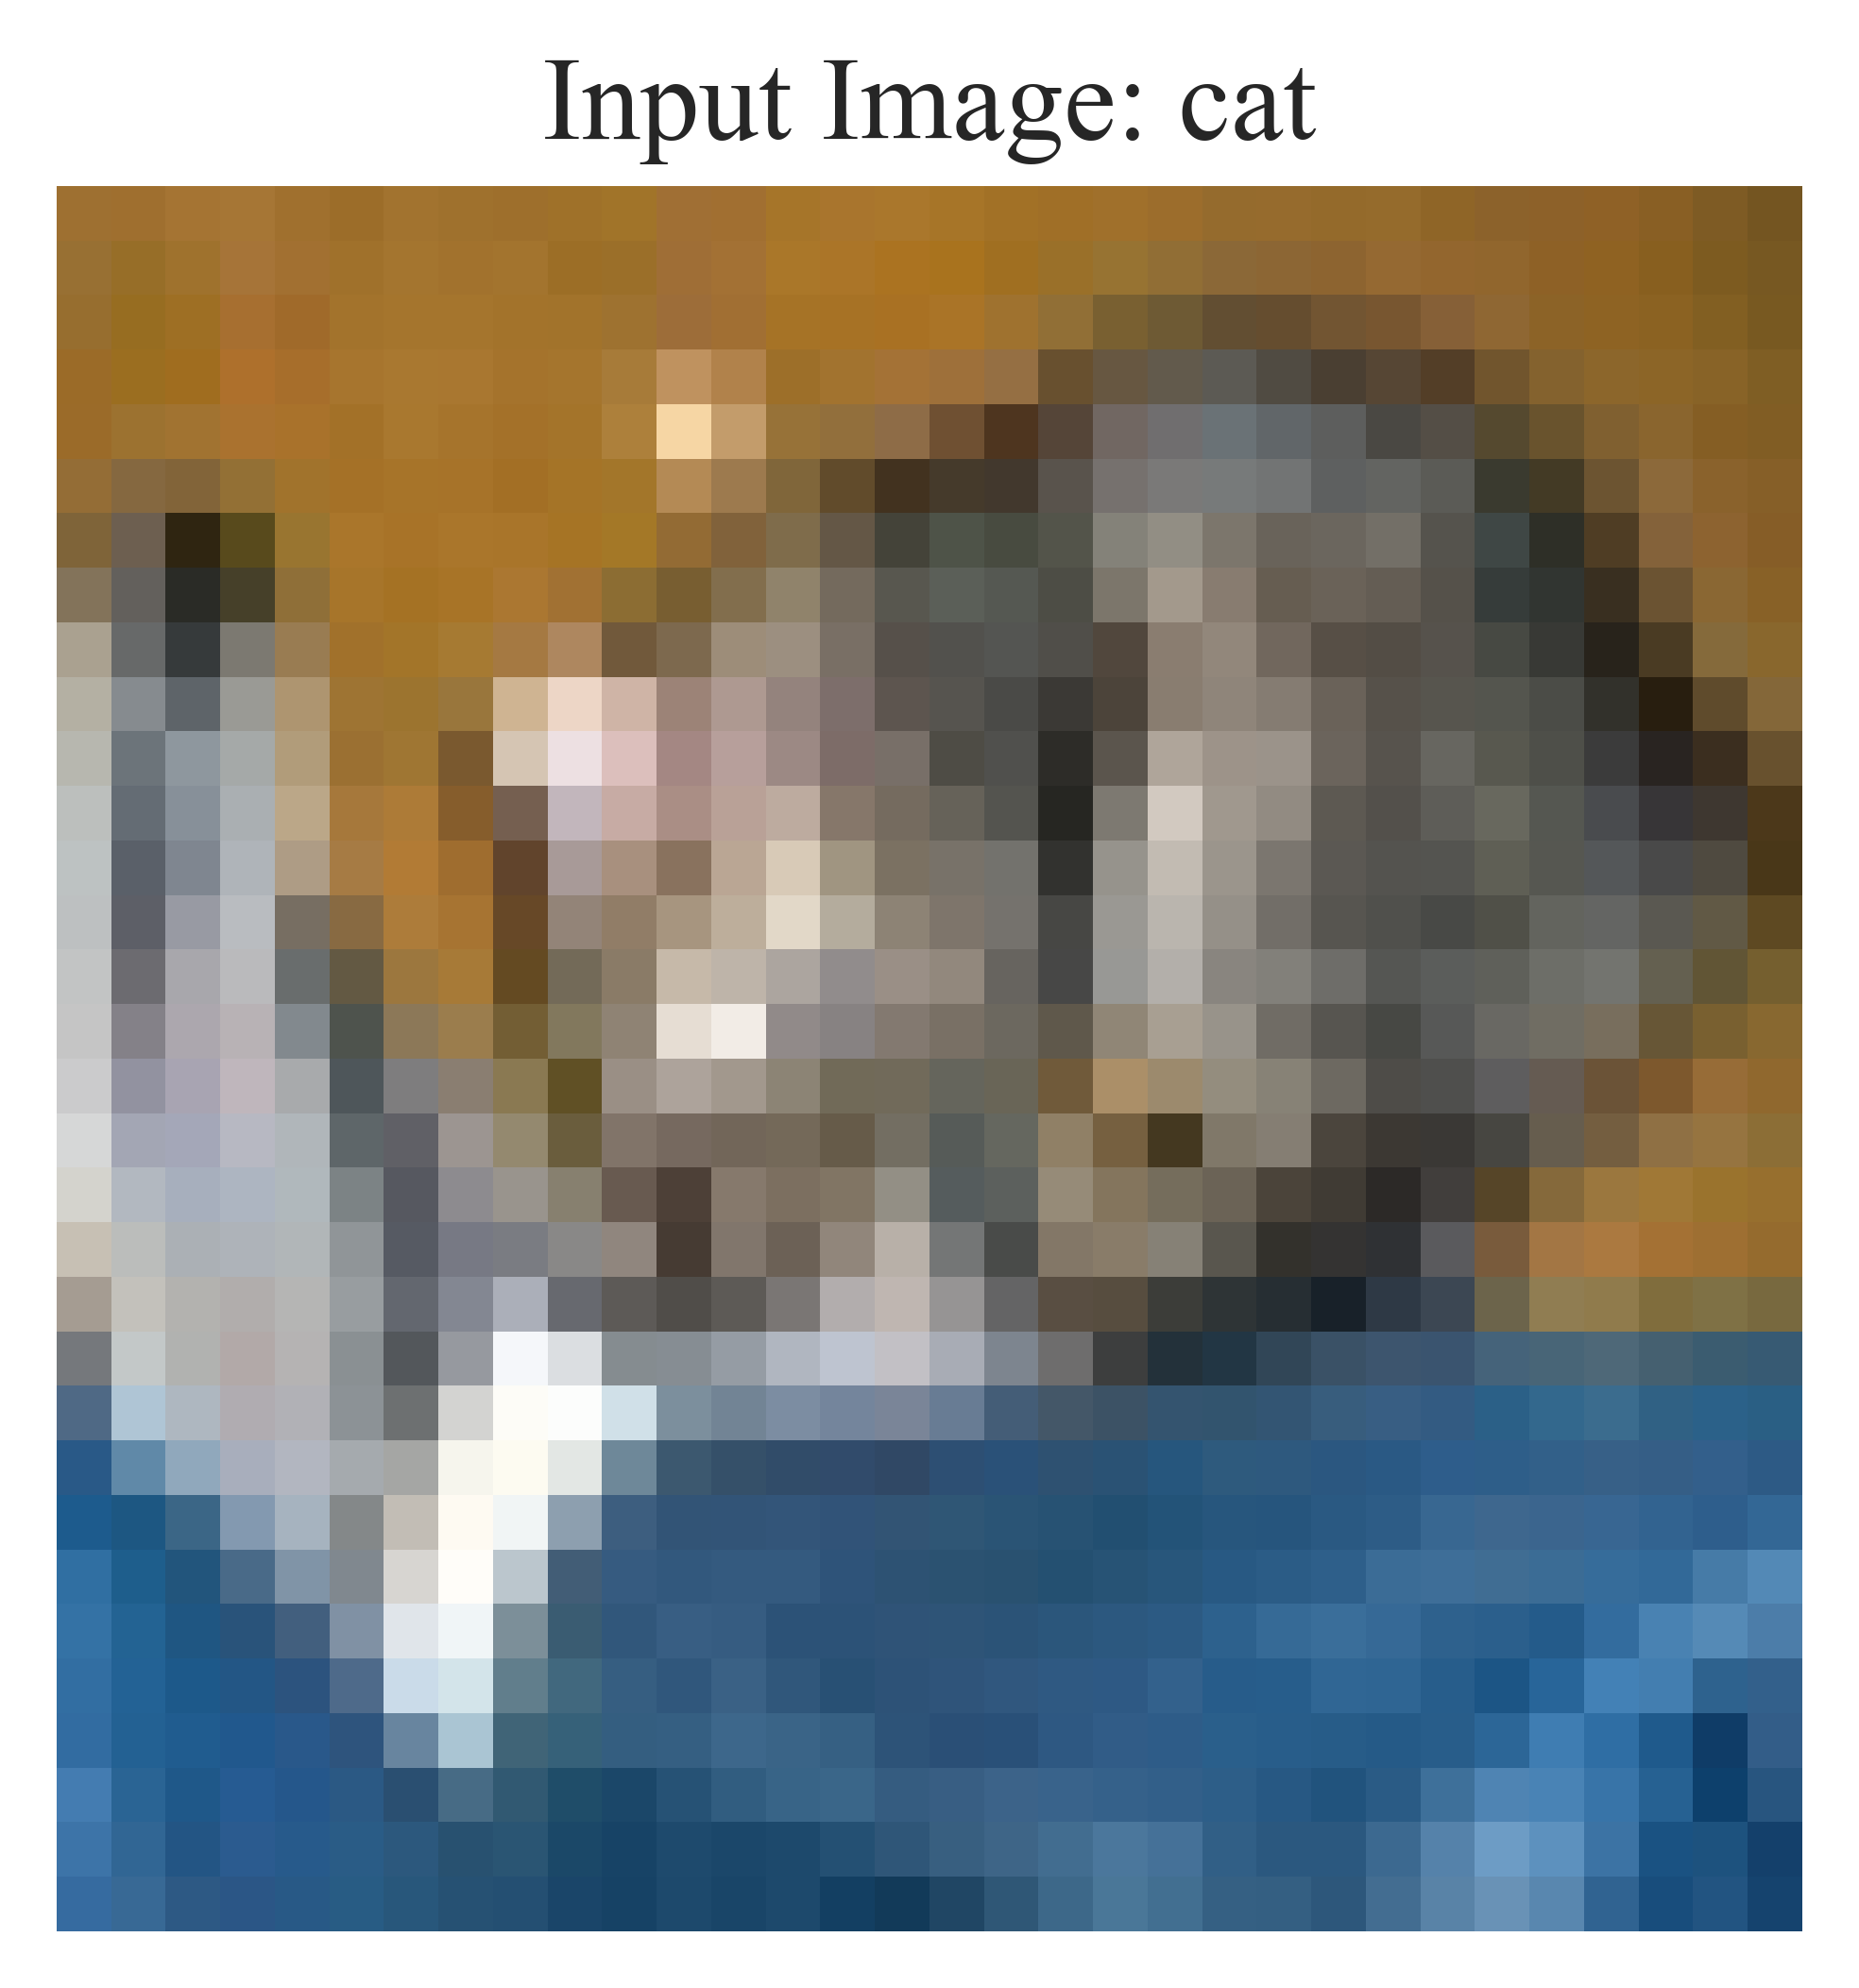

In [19]:
conv_layer_names = [layer.name for layer in model.layers if 'conv' in layer.name]
layer_outputs = [model.get_layer(name).output for name in conv_layer_names]
activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

sample_img = x_test[0:1]

plt.figure(figsize=(4, 4))
plt.imshow(x_test[0])
plt.title(f"Input Image: {class_names[y_true[0]]}", **title_style)
plt.axis('off')

plt.savefig(
    "feature_map_input_image.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

activations = activation_model.predict(sample_img, verbose=0)


Layer 'conv1' output shape: (1, 32, 32, 32)


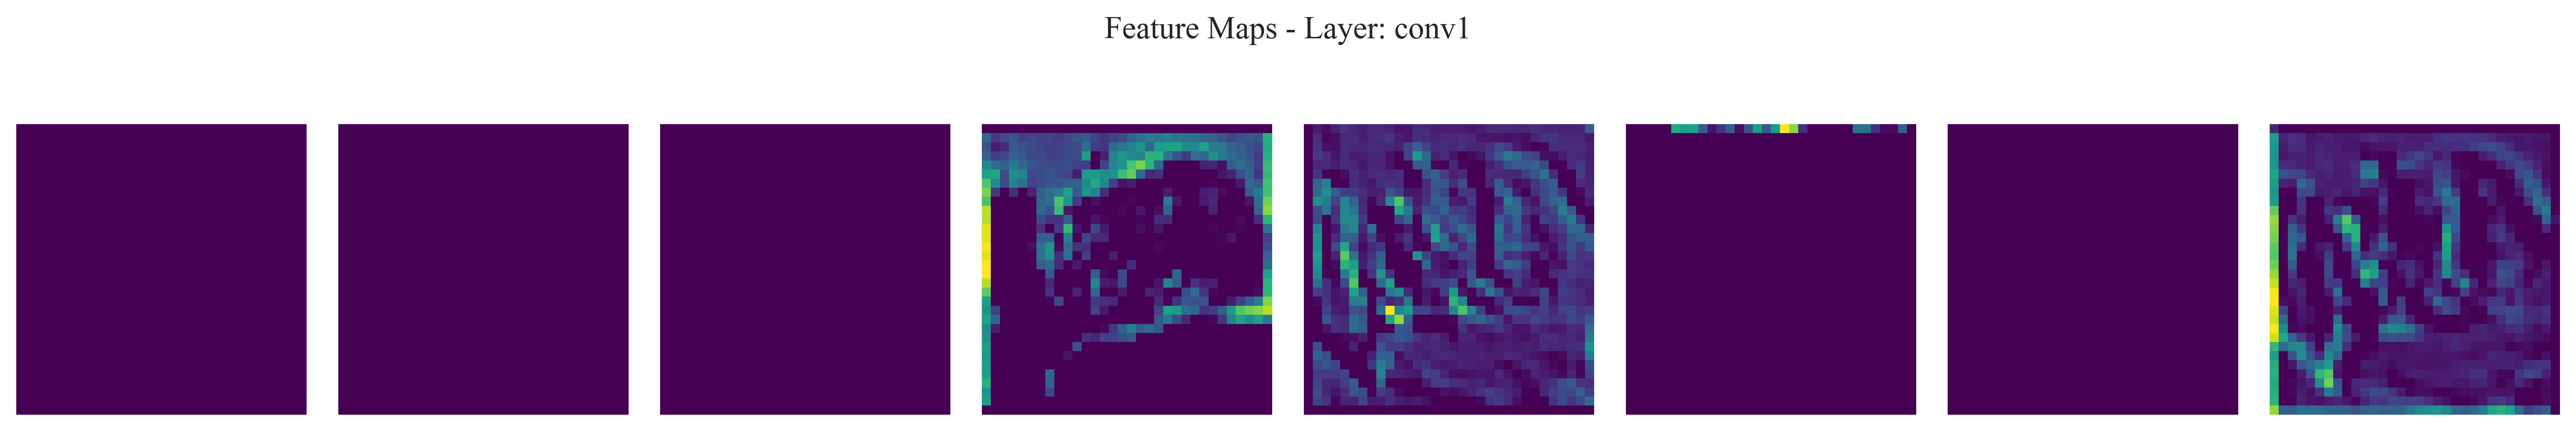

Layer 'conv2' output shape: (1, 32, 32, 32)


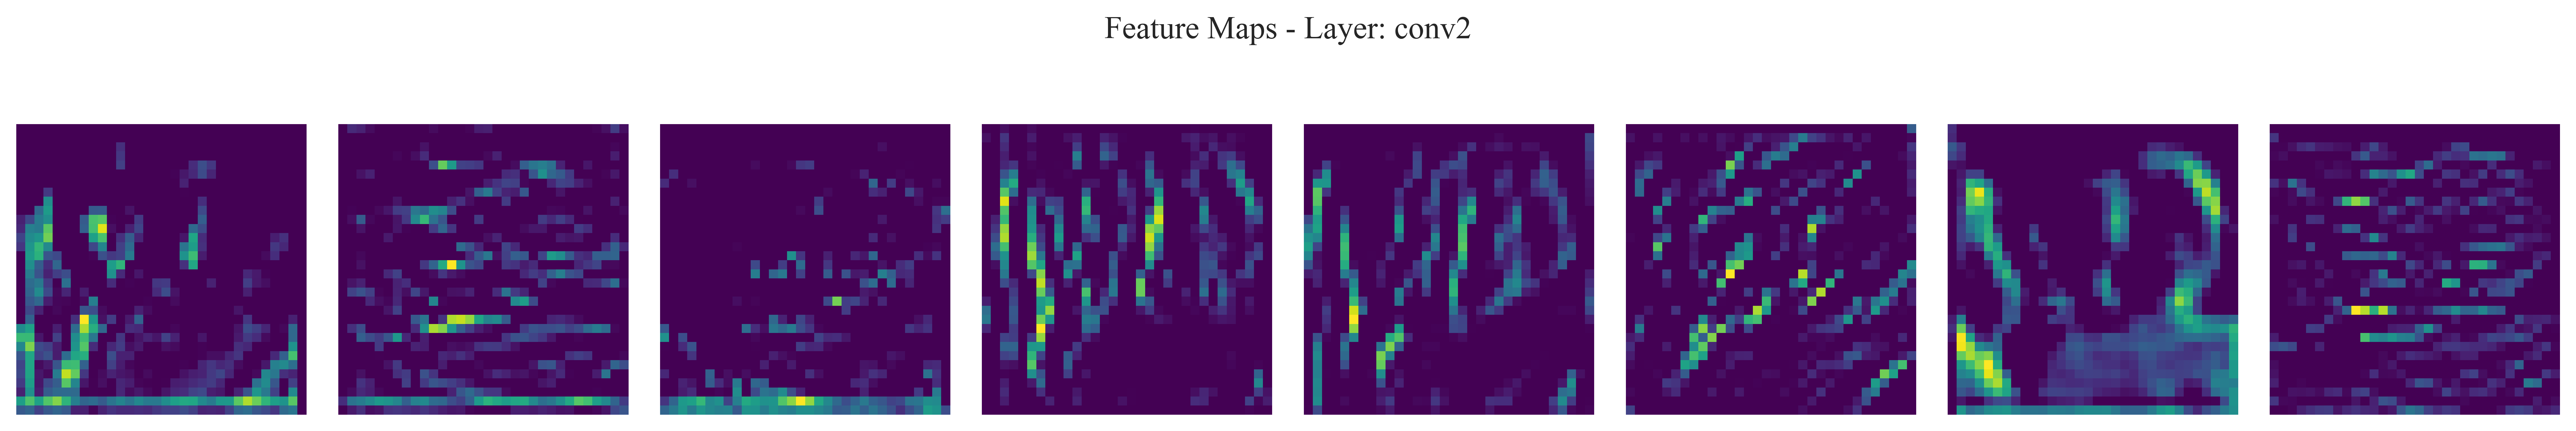

Layer 'conv3' output shape: (1, 16, 16, 64)


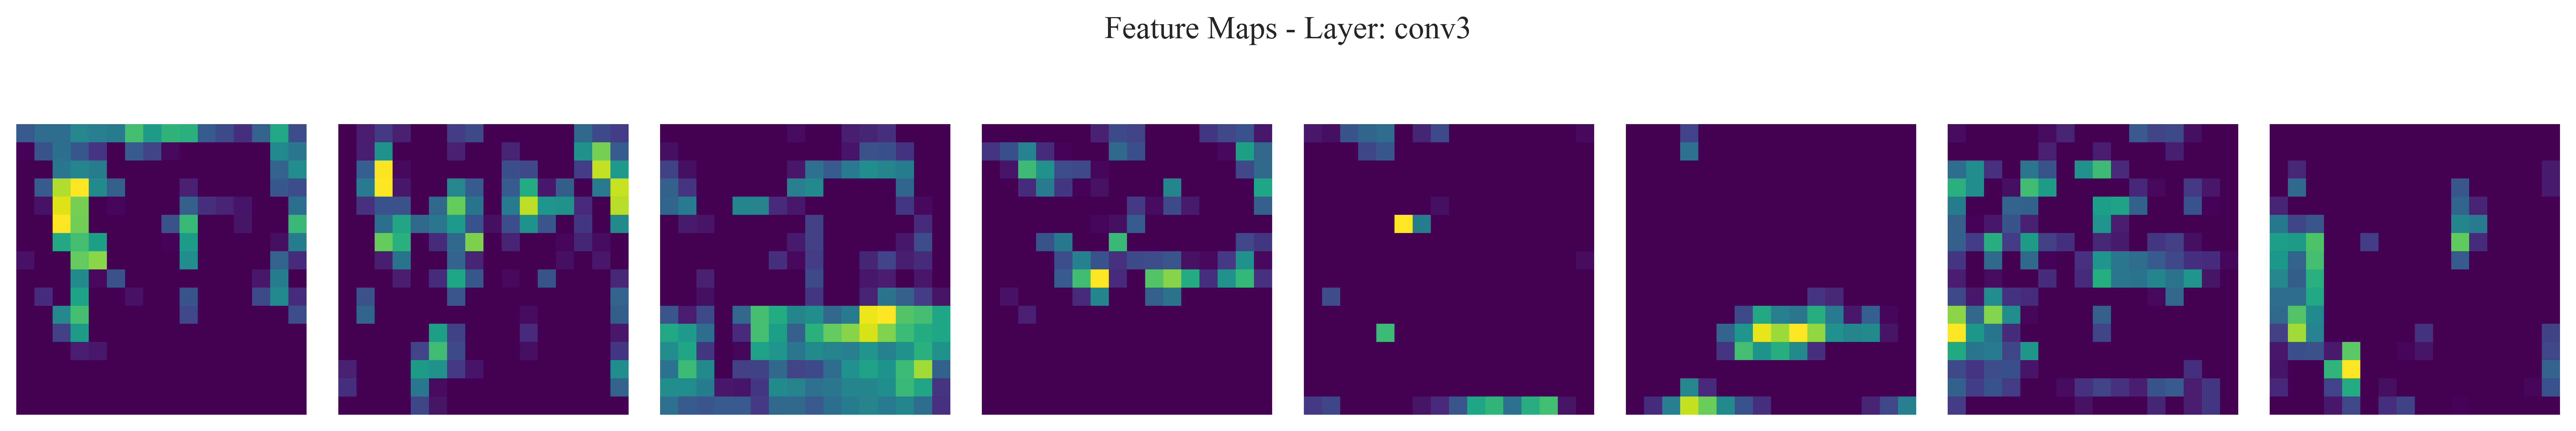

Layer 'conv4' output shape: (1, 16, 16, 64)


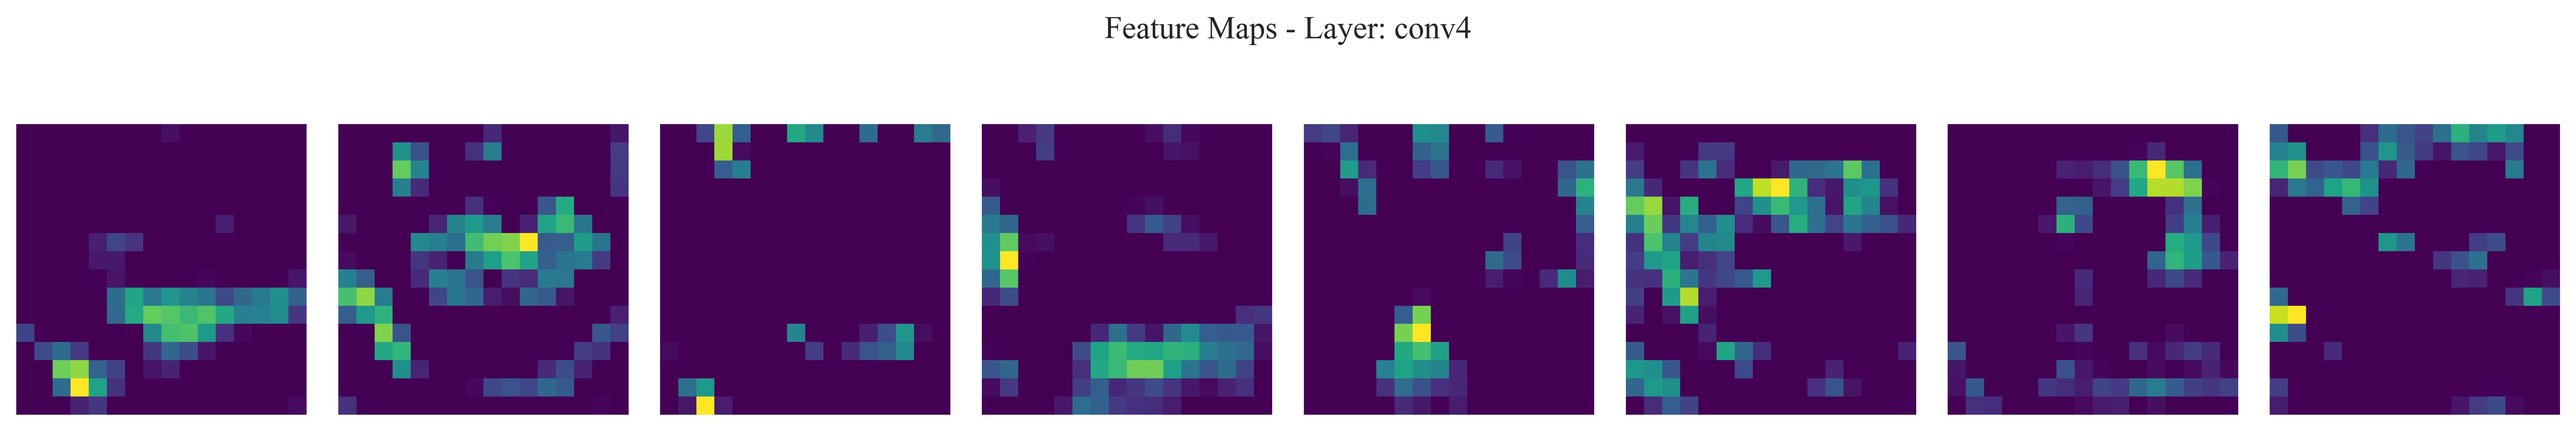

Layer 'conv5' output shape: (1, 8, 8, 128)


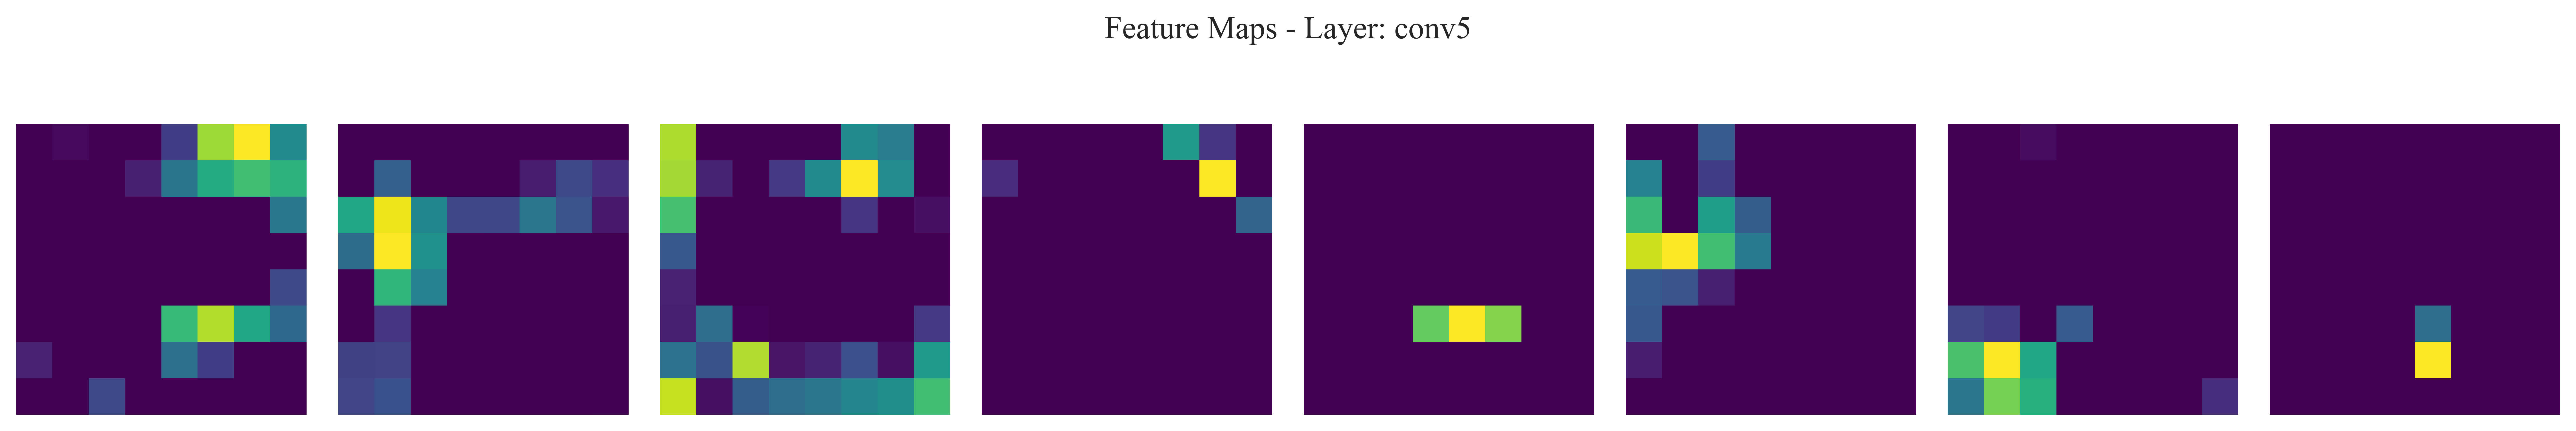

In [20]:
def plot_feature_maps(activation, layer_name, num_maps=8):
    num_maps = min(num_maps, activation.shape[-1])
    fmap_fig, fmap_axes = plt.subplots(1, num_maps, figsize=(num_maps * 2, 2.5))

    for i in range(num_maps):
        fmap_axes[i].imshow(activation[0, :, :, i], cmap='viridis')
        fmap_axes[i].axis('off')

    fmap_fig.suptitle(f"Feature Maps - Layer: {layer_name}", y=1.05,
                       fontsize=14, fontweight='bold', fontname='Times New Roman')
    fmap_fig.tight_layout()

    fmap_fig.savefig(
        f"feature_maps_{layer_name}.eps",
        format='eps',
        dpi=600,
        bbox_inches='tight'
    )

    plt.show()
    plt.close(fmap_fig)

for name, activation in zip(conv_layer_names, activations):
    print(f"Layer '{name}' output shape: {activation.shape}")
    plot_feature_maps(activation, name, num_maps=8)

**Observation:** Feature maps from early convolutional layers (e.g., `conv1`, `conv2`) tend to highlight low-level features such as edges, corners, and color blobs, closely resembling the input image. Feature maps from deeper layers (e.g., `conv5`) become increasingly abstract and sparse, representing higher-level, more class-discriminative patterns — illustrating the hierarchical feature learning behavior of CNNs.

## 12. Comparing Pooling Strategies: Max Pooling vs Average Pooling

We build two smaller CNNs, identical except for the pooling operation, and compare their performance and behavior on a subset of the data for a quick comparison (to keep training time reasonable within this experiment).


In [21]:
def build_small_cnn(pooling_type='max'):
    small_inputs = keras.Input(shape=(32, 32, 3))
    PoolLayer = layers.MaxPooling2D if pooling_type == 'max' else layers.AveragePooling2D

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(small_inputs)
    x = PoolLayer(pool_size=(2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = PoolLayer(pool_size=(2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    small_outputs = layers.Dense(10, activation='softmax')(x)

    small_model = keras.Model(inputs=small_inputs, outputs=small_outputs, name=f"CNN_{pooling_type}_pool")
    small_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return small_model

# Use a subset for a quick, fair comparison
subset = 10000
results = {}

for pool_type in ['max', 'average']:
    print(f"\n--- Training with {pool_type.upper()} pooling ---")
    m = build_small_cnn(pool_type)
    h = m.fit(x_train_final[:subset], y_train_final[:subset],
              validation_data=(x_val, y_val_cat),
              epochs=8, batch_size=64, verbose=0)
    test_loss, test_acc = m.evaluate(x_test, y_test_cat, verbose=0)
    results[pool_type] = {'history': h, 'test_acc': test_acc, 'test_loss': test_loss}
    print(f"{pool_type.capitalize()} Pooling -> Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")



--- Training with MAX pooling ---
Max Pooling -> Test Accuracy: 0.5567, Test Loss: 1.2640

--- Training with AVERAGE pooling ---
Average Pooling -> Test Accuracy: 0.5432, Test Loss: 1.2976


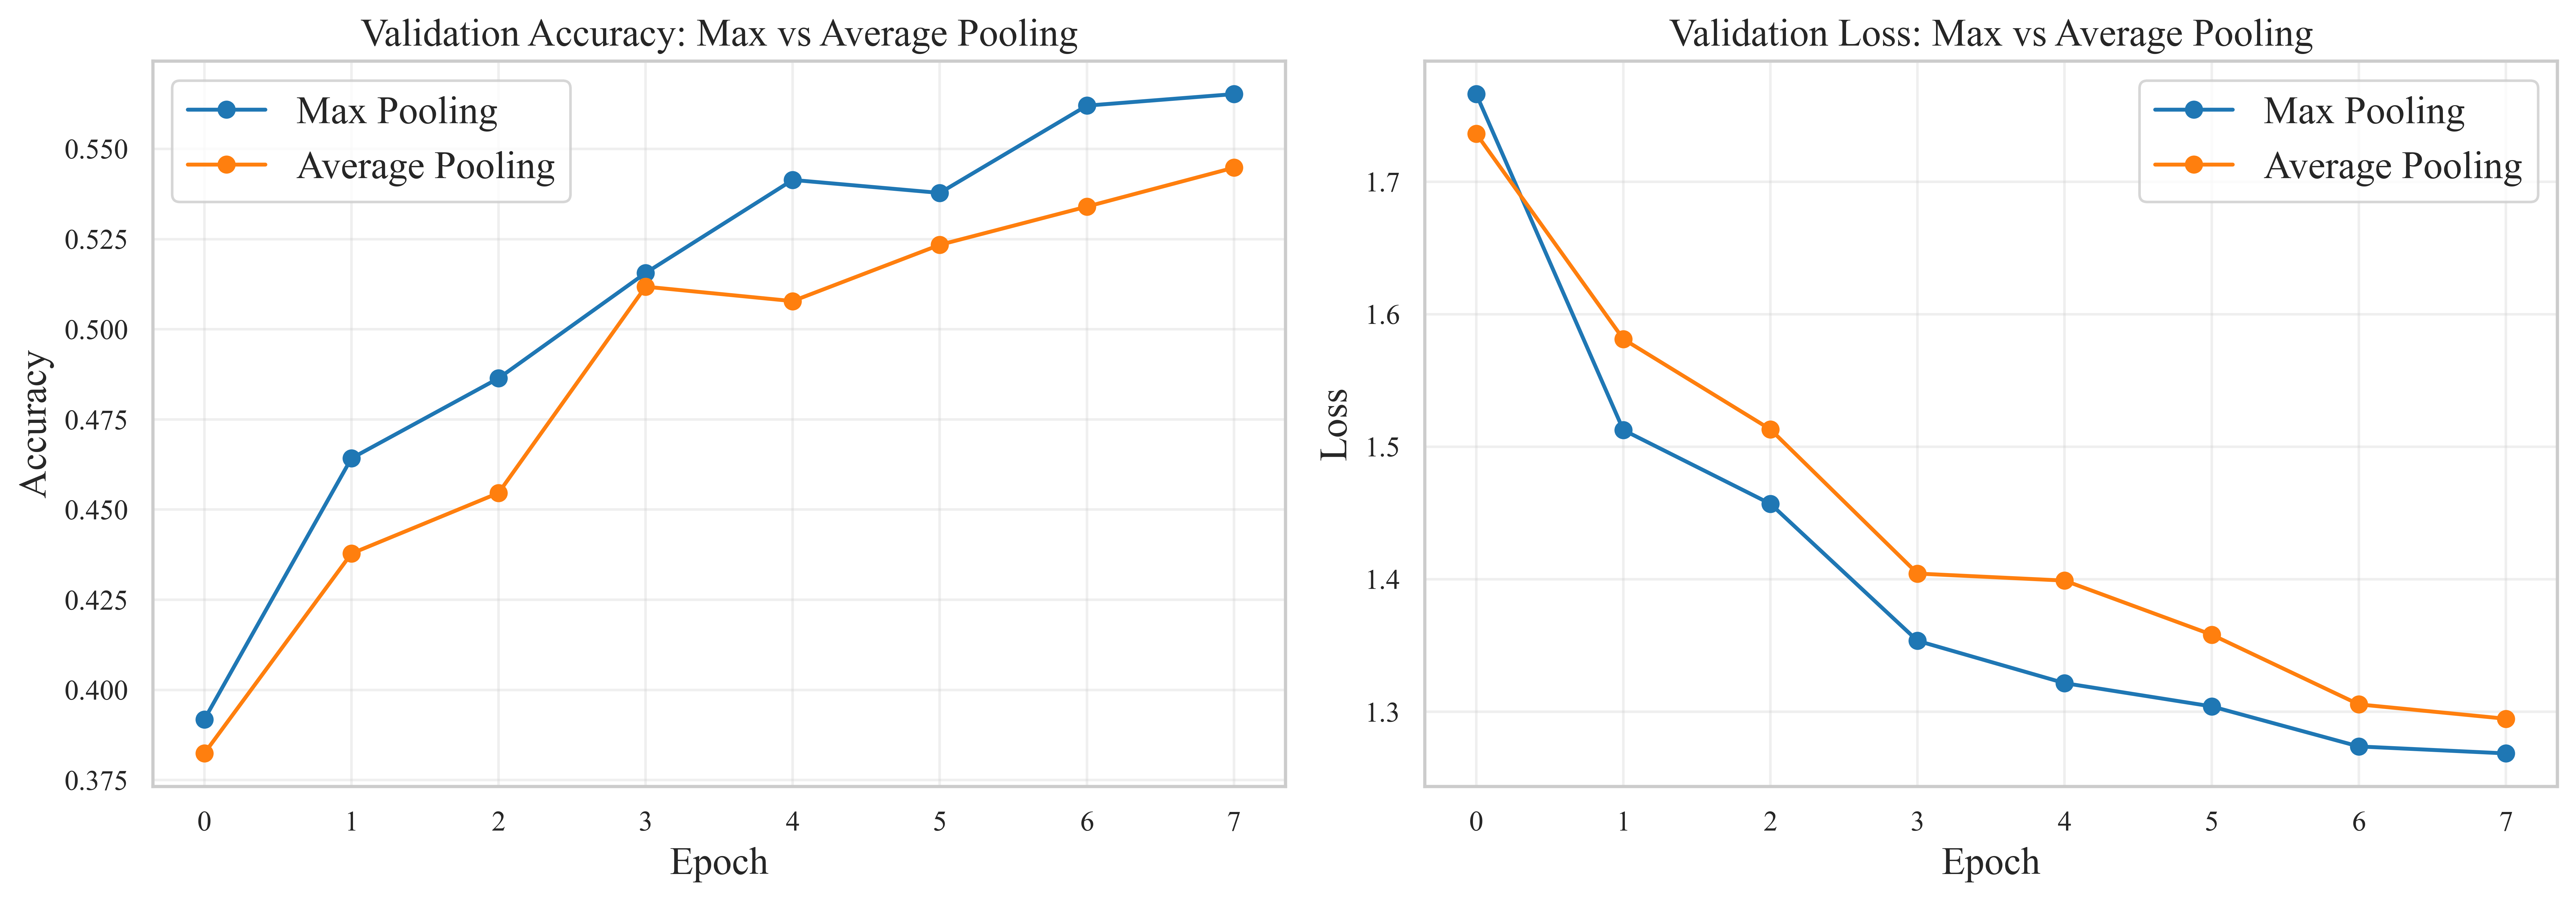


Summary:
Max Pooling -> Test Accuracy: 0.5567
Average Pooling -> Test Accuracy: 0.5432


In [22]:
pool_fig, pool_axes = plt.subplots(1, 2, figsize=(14, 5))

acc_axis = pool_axes[0]
loss_axis = pool_axes[1]

for pool_type in results:
    acc_axis.plot(results[pool_type]['history'].history['val_accuracy'],
                  label=f'{pool_type.capitalize()} Pooling', marker='o')
    loss_axis.plot(results[pool_type]['history'].history['val_loss'],
                   label=f'{pool_type.capitalize()} Pooling', marker='o')

acc_axis.set_title('Validation Accuracy: Max vs Average Pooling', **title_style)
acc_axis.set_xlabel('Epoch', **label_style)
acc_axis.set_ylabel('Accuracy', **label_style)
acc_legend = acc_axis.legend(prop=legend_style)
format_axis_ticks(acc_axis)
format_legend_text(acc_legend)
acc_axis.grid(alpha=0.3)

loss_axis.set_title('Validation Loss: Max vs Average Pooling', **title_style)
loss_axis.set_xlabel('Epoch', **label_style)
loss_axis.set_ylabel('Loss', **label_style)
loss_legend = loss_axis.legend(prop=legend_style)
format_axis_ticks(loss_axis)
format_legend_text(loss_legend)
loss_axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "pooling_comparison.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()

print("\nSummary:")
for pool_type in results:
    print(f"{pool_type.capitalize()} Pooling -> Test Accuracy: {results[pool_type]['test_acc']:.4f}")


**Observation:** Max Pooling typically preserves the most salient/dominant features (e.g., strong edges) by picking the maximum activation in each window, which often makes it more effective for classification tasks involving distinctive object features. Average Pooling smooths the feature map by averaging activations, which can retain more background/contextual information but may dilute strong discriminative signals. In most image classification benchmarks (including CIFAR-10), Max Pooling tends to converge faster and yield comparable or better accuracy.

## 13. Effect of Hyperparameters — Quick Experiment

We vary a single hyperparameter (batch size) while keeping others constant, training briefly on a subset, to observe its effect on convergence.



--- Training with batch_size=32 ---
Batch size 32 -> Test Accuracy: 0.5855

--- Training with batch_size=128 ---


Batch size 128 -> Test Accuracy: 0.5145


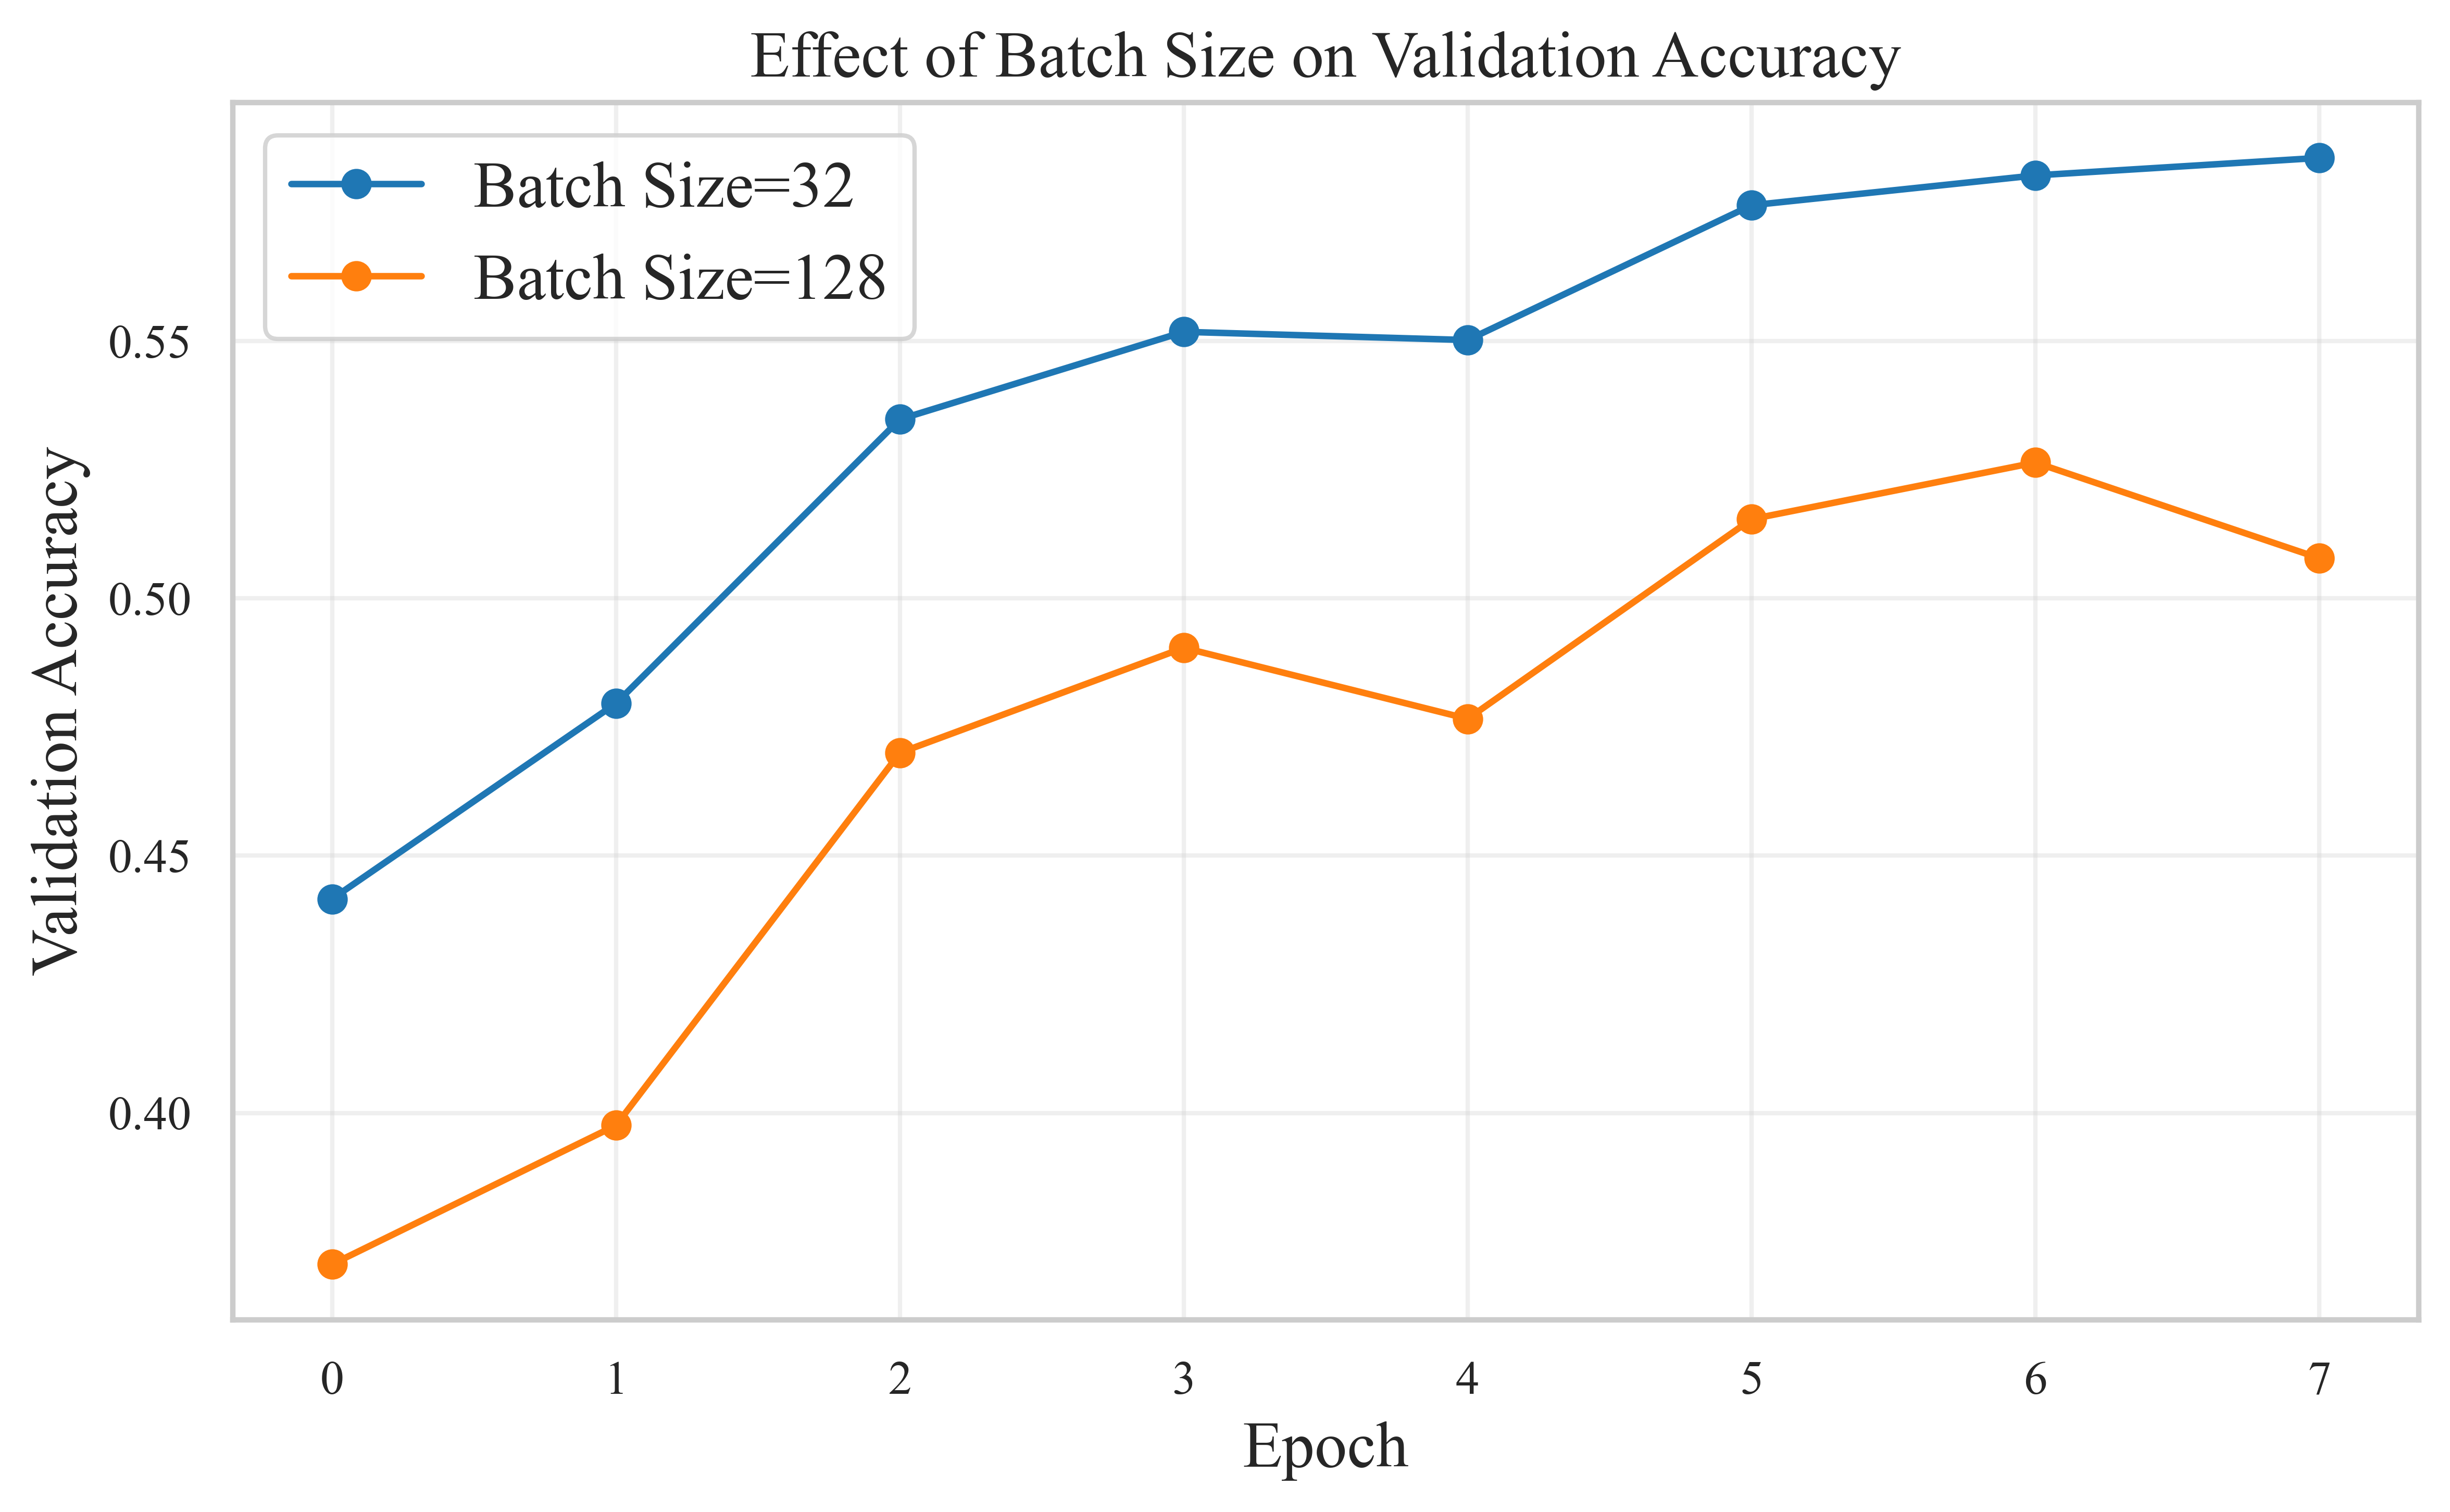

In [23]:
batch_sizes = [32, 128]
bs_results = {}

for bs in batch_sizes:
    print(f"\n--- Training with batch_size={bs} ---")
    m = build_small_cnn('max')
    h = m.fit(x_train_final[:subset], y_train_final[:subset],
              validation_data=(x_val, y_val_cat),
              epochs=8, batch_size=bs, verbose=0)
    test_loss, test_acc = m.evaluate(x_test, y_test_cat, verbose=0)
    bs_results[bs] = {'history': h, 'test_acc': test_acc}
    print(f"Batch size {bs} -> Test Accuracy: {test_acc:.4f}")

plt.figure(figsize=(8, 5))
bs_axis = plt.gca()

for bs in bs_results:
    bs_axis.plot(bs_results[bs]['history'].history['val_accuracy'],
                 label=f'Batch Size={bs}', marker='o')

bs_axis.set_title('Effect of Batch Size on Validation Accuracy', **title_style)
bs_axis.set_xlabel('Epoch', **label_style)
bs_axis.set_ylabel('Validation Accuracy', **label_style)
bs_legend = bs_axis.legend(prop=legend_style)
format_axis_ticks(bs_axis)
format_legend_text(bs_legend)
bs_axis.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "batch_size_comparison.eps",
    format='eps',
    dpi=600,
    bbox_inches='tight'
)

plt.show()


## 14. Conclusion

- A CNN with three convolutional blocks (Conv2D + BatchNorm + MaxPooling) was successfully designed, trained, and evaluated on the CIFAR-10 dataset.
- The convolutional layers progressively extract features from low-level edges/textures (early layers) to abstract, class-discriminative patterns (deeper layers), as confirmed by feature map visualization.
- Model performance was quantified using accuracy, precision, recall, F1-score, the confusion matrix, and a detailed classification report.
- Max Pooling and Average Pooling were compared, showing how the choice of pooling strategy affects feature retention and model performance.
- Hyperparameters such as batch size, kernel size, stride, padding, number of filters, and optimizer choice were shown to meaningfully influence training dynamics and final accuracy.
- This experiment provided practical, hands-on experience in applying deep learning and CNN architecture design principles to a real-world computer vision classification problem.


## 15. Download All EPS Plots (600 DPI, Times New Roman) as a ZIP

All figures generated above were saved as individual `.eps` files at 600 DPI with Times New Roman formatting. This final cell collects all of them into a single ZIP archive and triggers a download (Colab only).


> **Note on file size:** Plots built from `imshow()` (sample images, feature maps, sample predictions) embed raster image data uncompressed in EPS, so at 600 DPI these individual files can be tens of MB each and the full ZIP can reach several hundred MB. Line/bar/heatmap-style plots (training curves, confusion matrix, class distribution, pooling comparison) stay small (tens of KB to a few MB). If ZIP size becomes an issue in Colab, consider lowering `dpi` specifically for the image-heavy plots, or export those as high-resolution PNG instead of EPS.

## 16. Task 2 — Effect of Kernel Size (3×3, 5×5, 7×7)

*Added to satisfy the lab manual's Task 2, which was not in the original notebook. This cell only needs `x_train` (already loaded in Section 3), so it can be run on its own without re-running anything above.*

A single convolution layer is applied to one sample image using three different kernel sizes, with `'valid'` padding and stride 1, to directly observe how kernel size affects the output feature map's spatial dimensions.


In [24]:
sample_image_for_kernels = x_train[0:1]  # x_train is already normalized to [0,1] from Section 4

print(f"Input image shape: {sample_image_for_kernels.shape}\n")

kernel_sizes = [3, 5, 7]
kernel_size_outputs = {}

for k in kernel_sizes:
    conv_layer = layers.Conv2D(filters=8, kernel_size=k, strides=1, padding='valid')
    output = conv_layer(sample_image_for_kernels)
    kernel_size_outputs[k] = output.shape
    # Manual verification using the formula from the lab manual: (N - F + 2P) / S + 1
    N, F, P, S = sample_image_for_kernels.shape[1], k, 0, 1
    computed_size = (N - F + 2 * P) // S + 1
    print(f"Kernel {k}x{k} -> Output shape: {tuple(output.shape)}  "
          f"(formula check: (({N}-{F}+2*{P})/{S})+1 = {computed_size})")


Input image shape: (1, 32, 32, 3)

Kernel 3x3 -> Output shape: (1, 30, 30, 8)  (formula check: ((32-3+2*0)/1)+1 = 30)
Kernel 5x5 -> Output shape: (1, 28, 28, 8)  (formula check: ((32-5+2*0)/1)+1 = 28)
Kernel 7x7 -> Output shape: (1, 26, 26, 8)  (formula check: ((32-7+2*0)/1)+1 = 26)


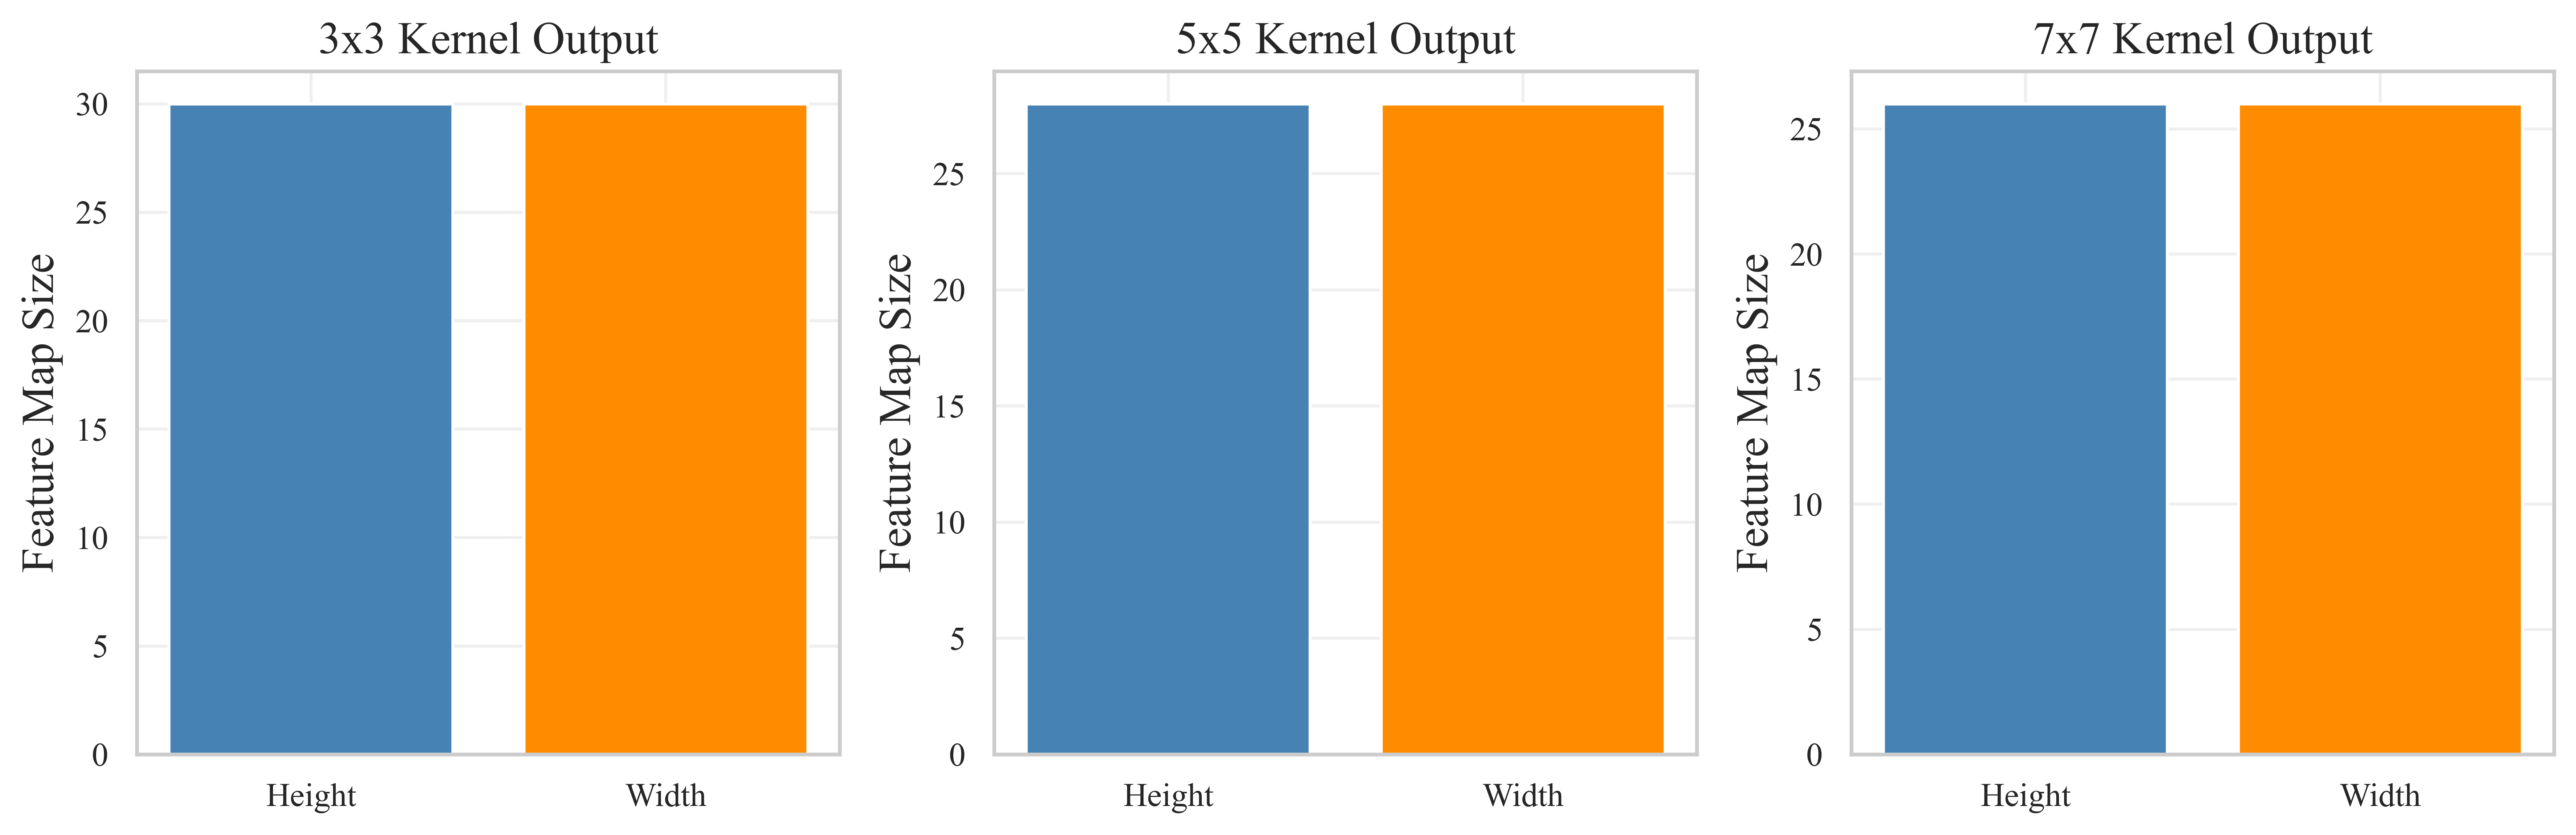

In [25]:
kernel_fig, kernel_axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, k in zip(kernel_axes, kernel_sizes):
    ax.bar(['Height', 'Width'], [kernel_size_outputs[k][1], kernel_size_outputs[k][2]], color=['steelblue', 'darkorange'])
    ax.set_title(f'{k}x{k} Kernel Output', **title_style)
    ax.set_ylabel('Feature Map Size', **label_style)
    format_axis_ticks(ax)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("kernel_size_comparison.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Larger kernels shrink the output feature map faster under `'valid'` padding, since each kernel position "eats into" more of the border -- a 7×7 kernel on a 32×32 image leaves a 26×26 output, while a 3×3 kernel only shrinks it to 30×30. This is exactly why `'same'` padding is used everywhere else in this notebook -- without it, stacking several convolutional layers would shrink the feature map very quickly.

## 17. Task 3 — Effect of Stride and Padding

*Added to satisfy the lab manual's Task 3. Only needs `x_train`, already loaded.*


In [26]:
sample_image_for_stride = x_train[0:1]

print("--- Stride Comparison (kernel=3x3, padding='valid') ---")
for stride in [1, 2]:
    conv_layer = layers.Conv2D(filters=8, kernel_size=3, strides=stride, padding='valid')
    output = conv_layer(sample_image_for_stride)
    N, F, P, S = 32, 3, 0, stride
    computed_size = (N - F + 2 * P) // S + 1
    print(f"Stride={stride} -> Output shape: {tuple(output.shape)}  "
          f"(formula check: (({N}-{F}+2*{P})/{S})+1 = {computed_size})")

print("\n--- Padding Comparison (kernel=3x3, stride=1) ---")
for padding in ['same', 'valid']:
    conv_layer = layers.Conv2D(filters=8, kernel_size=3, strides=1, padding=padding)
    output = conv_layer(sample_image_for_stride)
    print(f"Padding='{padding}' -> Output shape: {tuple(output.shape)}")


--- Stride Comparison (kernel=3x3, padding='valid') ---
Stride=1 -> Output shape: (1, 30, 30, 8)  (formula check: ((32-3+2*0)/1)+1 = 30)
Stride=2 -> Output shape: (1, 15, 15, 8)  (formula check: ((32-3+2*0)/2)+1 = 15)

--- Padding Comparison (kernel=3x3, stride=1) ---
Padding='same' -> Output shape: (1, 32, 32, 8)
Padding='valid' -> Output shape: (1, 30, 30, 8)


**Inference:** Stride 2 roughly halves the output spatial size compared to stride 1, since the kernel skips every other position -- a cheaper way to downsample than adding a separate pooling layer, at the cost of skipping some spatial detail. `'same'` padding keeps the output the exact same 32×32 size as the input by zero-padding the border, while `'valid'` padding (no padding at all) shrinks it to 30×30 -- confirming why every convolutional layer in the main CNN (Section 6) uses `'same'` padding: stacking many `'valid'`-padded layers would shrink the feature map to nothing well before reaching the classifier.

## 18. Task 5 (Supplement) — Pooling Output Size Comparison

Section 12 already compares Max Pooling vs. Average Pooling on accuracy. The lab manual also asks for an explicit **output size** comparison, which this cell adds. Standalone -- doesn't depend on the `results` dictionary from Section 12.


In [27]:
sample_feature_map = tf.random.normal((1, 32, 32, 16))  # a stand-in feature map, e.g. after a conv layer

max_pool_output = layers.MaxPooling2D(pool_size=(2, 2))(sample_feature_map)
avg_pool_output = layers.AveragePooling2D(pool_size=(2, 2))(sample_feature_map)

print(f"Input feature map shape : {tuple(sample_feature_map.shape)}")
print(f"Max Pooling output shape: {tuple(max_pool_output.shape)}")
print(f"Avg Pooling output shape: {tuple(avg_pool_output.shape)}")
print("\nBoth pooling types reduce the spatial size identically (32x32 -> 16x16) for the same")
print("pool size and stride -- the difference between them is entirely in the VALUES each")
print("window produces (max vs. mean), not the output shape, which is what Section 12's")
print("accuracy comparison actually captures.")


Input feature map shape : (1, 32, 32, 16)
Max Pooling output shape: (1, 16, 16, 16)
Avg Pooling output shape: (1, 16, 16, 16)

Both pooling types reduce the spatial size identically (32x32 -> 16x16) for the same
pool size and stride -- the difference between them is entirely in the VALUES each
window produces (max vs. mean), not the output shape, which is what Section 12's
accuracy comparison actually captures.


## 19. Task 6 — CNN Architecture per Lab Manual Specification

*The CNN built in Section 6 of this notebook is a larger, 5-convolution-layer architecture with batch normalization and dropout, trained for 30 epochs at batch size 64 -- it does not match the lab manual's Task 6 specification exactly. Rather than rebuild and retrain that existing model (which would mean re-running the entire notebook from Section 6 onward), this section builds a **new, separate model** that matches the manual's specification exactly:*

$$\text{Input} \rightarrow \text{Conv} \rightarrow \text{ReLU} \rightarrow \text{MaxPool} \rightarrow \text{Conv} \rightarrow \text{ReLU} \rightarrow \text{MaxPool} \rightarrow \text{Flatten} \rightarrow \text{Dense} \rightarrow \text{Softmax}$$

trained with Adam, 20 epochs, batch size 32 -- exactly as specified. This only needs `x_train_final`, `y_train_final`, `x_val`, `y_val_cat`, `x_test`, `y_test_cat`, and `class_names`, all already in memory from Sections 3–4.


In [28]:
def build_manual_spec_cnn(input_shape=(32, 32, 3), num_classes=10):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, kernel_size=(3, 3), padding='same', name='manual_conv1')(inputs)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Conv2D(64, kernel_size=(3, 3), padding='same', name='manual_conv2')(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs, name="Manual_Spec_CNN")

baseline_model = build_manual_spec_cnn()
baseline_model.summary()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Model: "Manual_Spec_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ manual_conv1 (Conv2D)           │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ manual_conv2 (Conv2D)           │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 60,362 (235.79 KB)

 Trainable params: 60,362 (235.79 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
BASELINE_EPOCHS = 20
BASELINE_BATCH_SIZE = 32

baseline_history = baseline_model.fit(
    x_train_final, y_train_final,
    validation_data=(x_val, y_val_cat),
    epochs=BASELINE_EPOCHS,
    batch_size=BASELINE_BATCH_SIZE,
    verbose=1
)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.4912 - loss: 1.4382 - val_accuracy: 0.5922 - val_loss: 1.1598
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6240 - loss: 1.0814 - val_accuracy: 0.6442 - val_loss: 1.0172
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6741 - loss: 0.9422 - val_accuracy: 0.6648 - val_loss: 0.9616
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7060 - loss: 0.8570 - val_accuracy: 0.6766 - val_loss: 0.9362
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7282 - loss: 0.7909 - val_accuracy: 0.6834 - val_loss: 0.9237
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7484 - loss: 0.7359 - val_accuracy: 0.6916 - val_loss: 0.8987
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7637 - loss: 0.6903 - val_accuracy: 0.6998 - val_loss: 0.8886
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7767 - loss: 0.6498 

### 19.1 Evaluate the Manual-Specification Model

In [30]:
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss    : {baseline_test_loss:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")

baseline_y_pred_probs = baseline_model.predict(x_test, verbose=0)
baseline_y_pred = np.argmax(baseline_y_pred_probs, axis=1)
baseline_y_true = y_test.flatten()

baseline_precision = precision_score(baseline_y_true, baseline_y_pred, average='weighted', zero_division=0)
baseline_recall = recall_score(baseline_y_true, baseline_y_pred, average='weighted', zero_division=0)
baseline_f1 = f1_score(baseline_y_true, baseline_y_pred, average='weighted', zero_division=0)

print(f"Precision (weighted): {baseline_precision:.4f}")
print(f"Recall (weighted)   : {baseline_recall:.4f}")
print(f"F1-score (weighted) : {baseline_f1:.4f}")

total_baseline_params = baseline_model.count_params()
print(f"\nTotal Parameters: {total_baseline_params:,}")


Test Loss    : 1.4740
Test Accuracy: 0.6587
Precision (weighted): 0.6701
Recall (weighted)   : 0.6587
F1-score (weighted) : 0.6606

Total Parameters: 60,362


### 19.2 Classification Report

In [31]:
print(classification_report(baseline_y_true, baseline_y_pred, target_names=class_names, zero_division=0))


              precision    recall  f1-score   support

    airplane       0.65      0.77      0.71      1000
  automobile       0.84      0.73      0.78      1000
        bird       0.59      0.48      0.53      1000
         cat       0.46      0.51      0.48      1000
        deer       0.61      0.60      0.61      1000
         dog       0.50      0.62      0.55      1000
        frog       0.83      0.64      0.72      1000
       horse       0.70      0.72      0.71      1000
        ship       0.73      0.82      0.77      1000
       truck       0.78      0.70      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



### 19.3 Confusion Matrix (Manual-Specification Model)

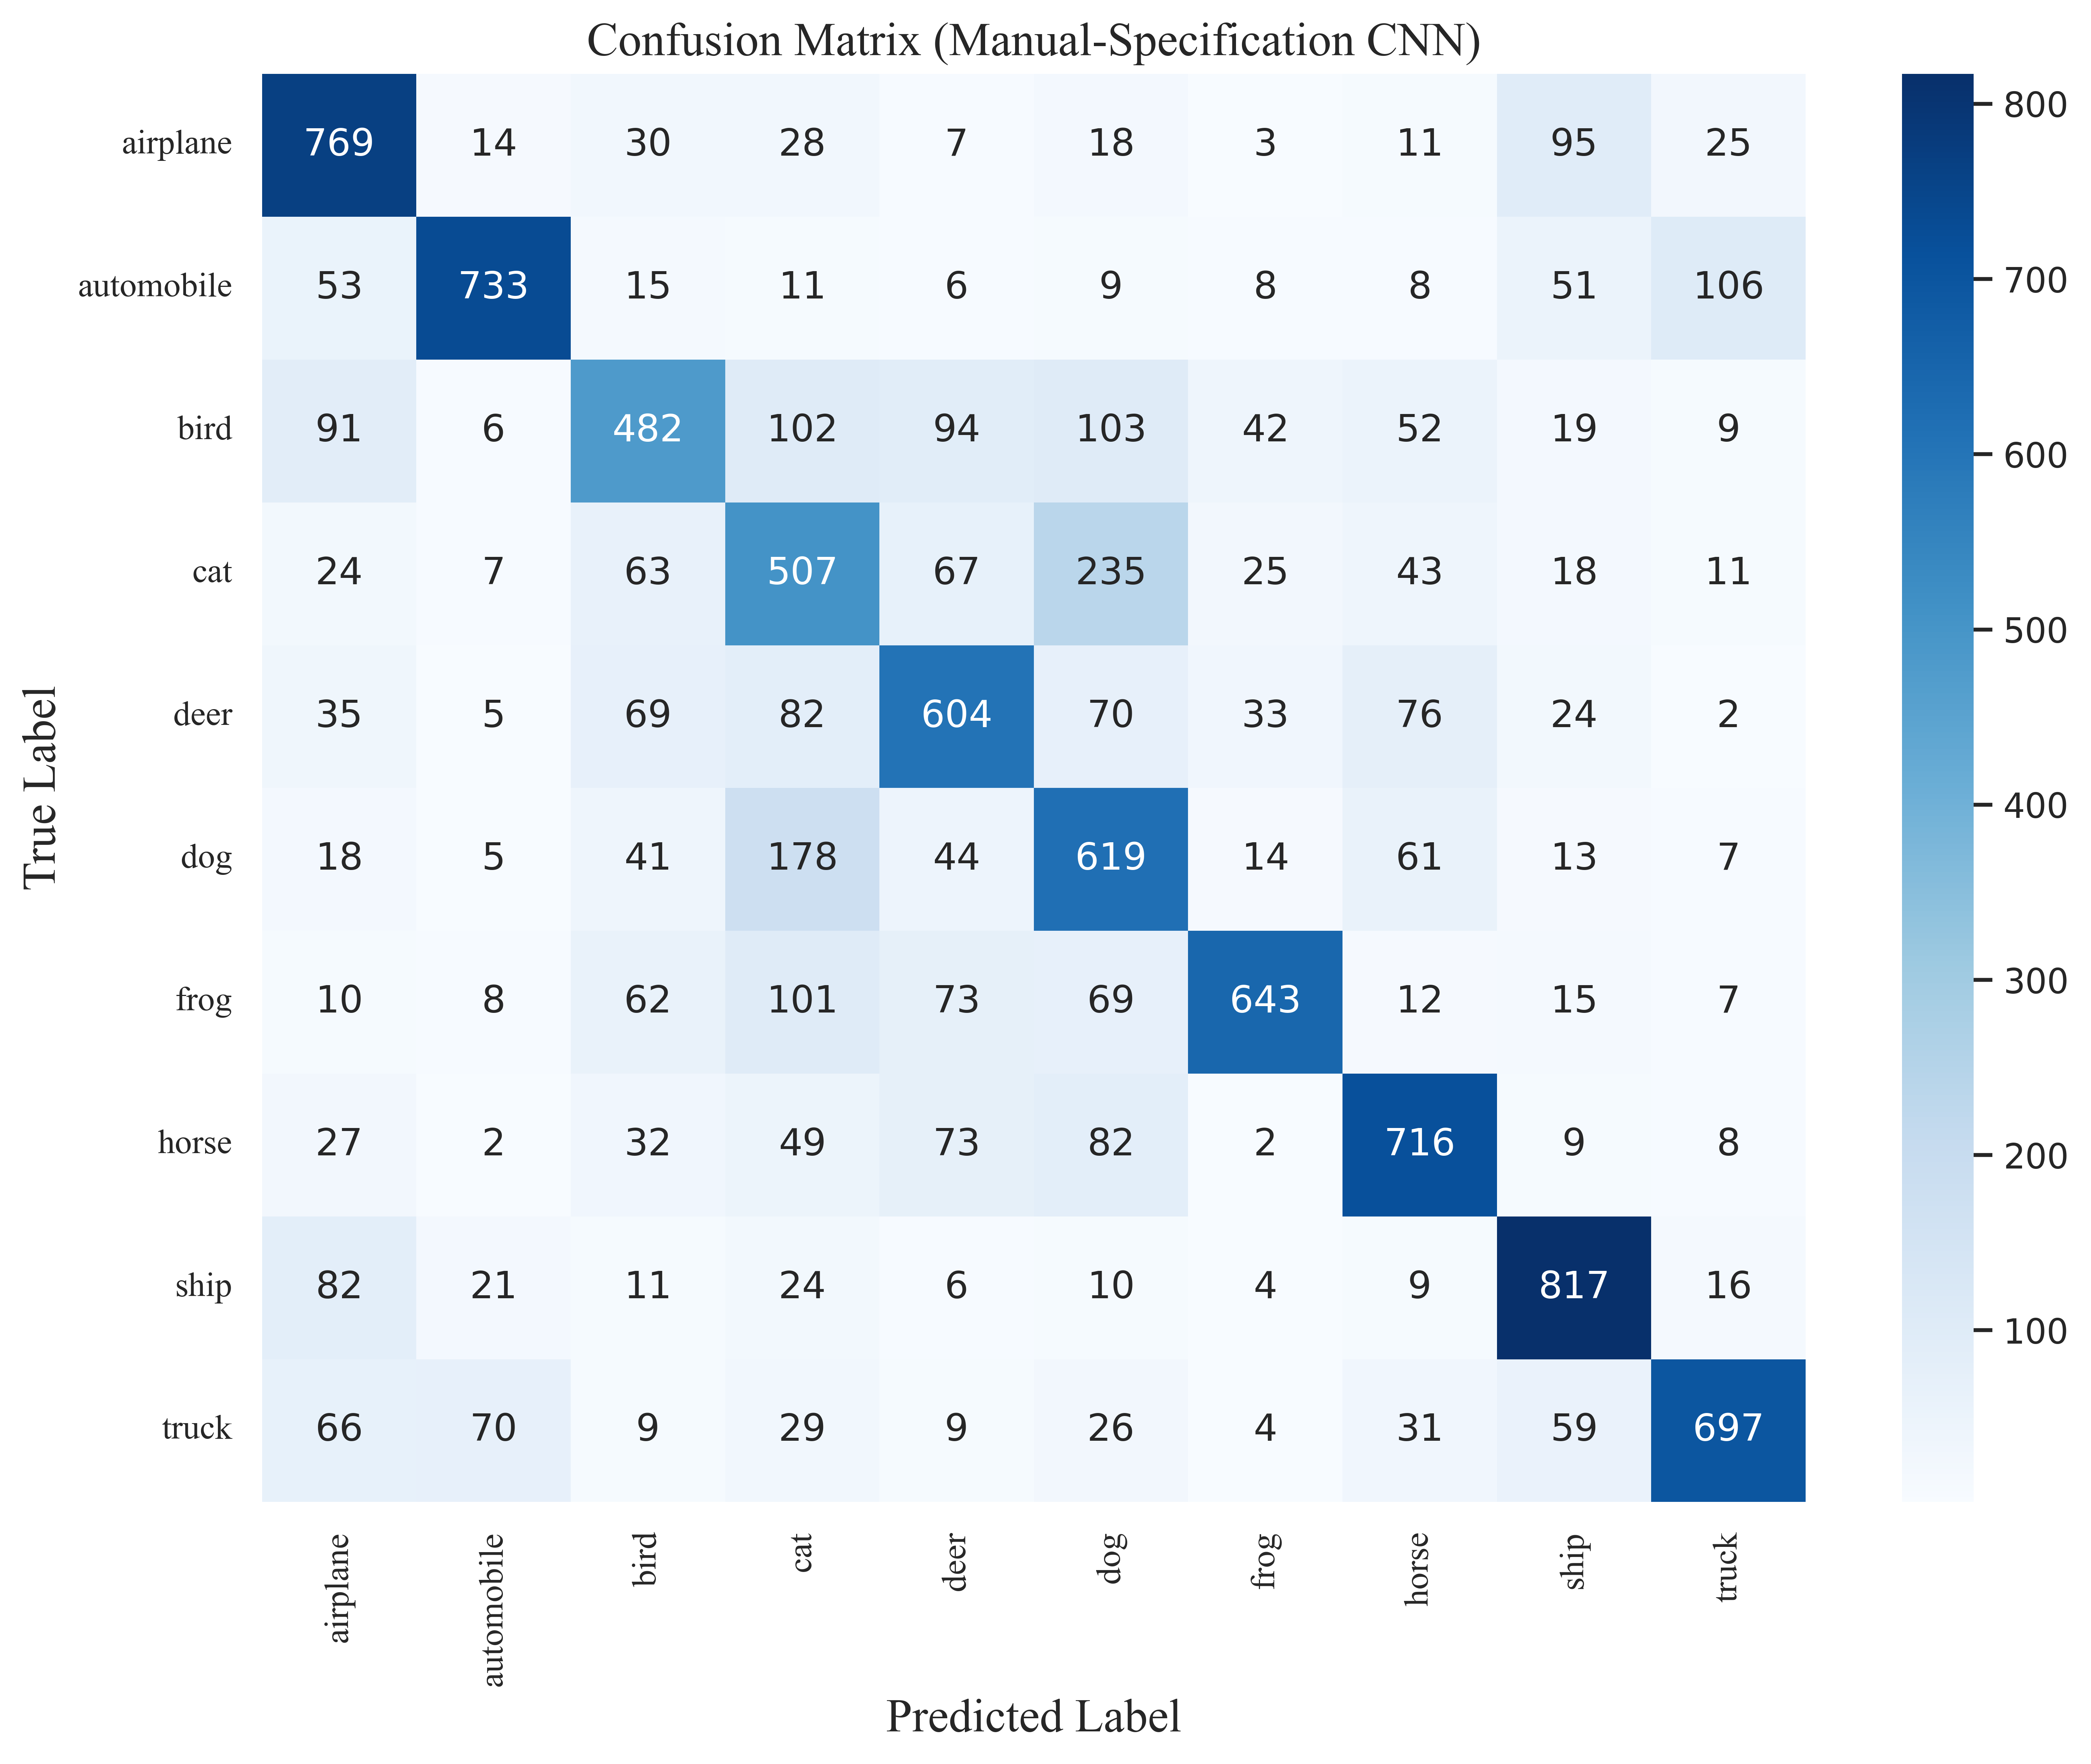

In [32]:
baseline_cm = confusion_matrix(baseline_y_true, baseline_y_pred)

plt.figure(figsize=(10, 8))
baseline_cm_axis = sns.heatmap(baseline_cm, annot=True, fmt='d', cmap='Blues',
                                xticklabels=class_names, yticklabels=class_names)
baseline_cm_axis.set_title('Confusion Matrix (Manual-Specification CNN)', **title_style)
baseline_cm_axis.set_xlabel('Predicted Label', **label_style)
baseline_cm_axis.set_ylabel('True Label', **label_style)
format_axis_ticks(baseline_cm_axis)
plt.tight_layout()
plt.savefig("confusion_matrix_manual_spec.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


## 20. Mandatory Plots — Training/Validation Accuracy and Loss (Separate Figures)

The lab manual lists Training Accuracy, Validation Accuracy, Training Loss, and Validation Loss as **four separate plots**, not one combined figure like Section 9's `training_curves.eps`. These four cells generate them individually, using the Manual-Specification model's training history from Section 19.


### 20.1 Training Accuracy

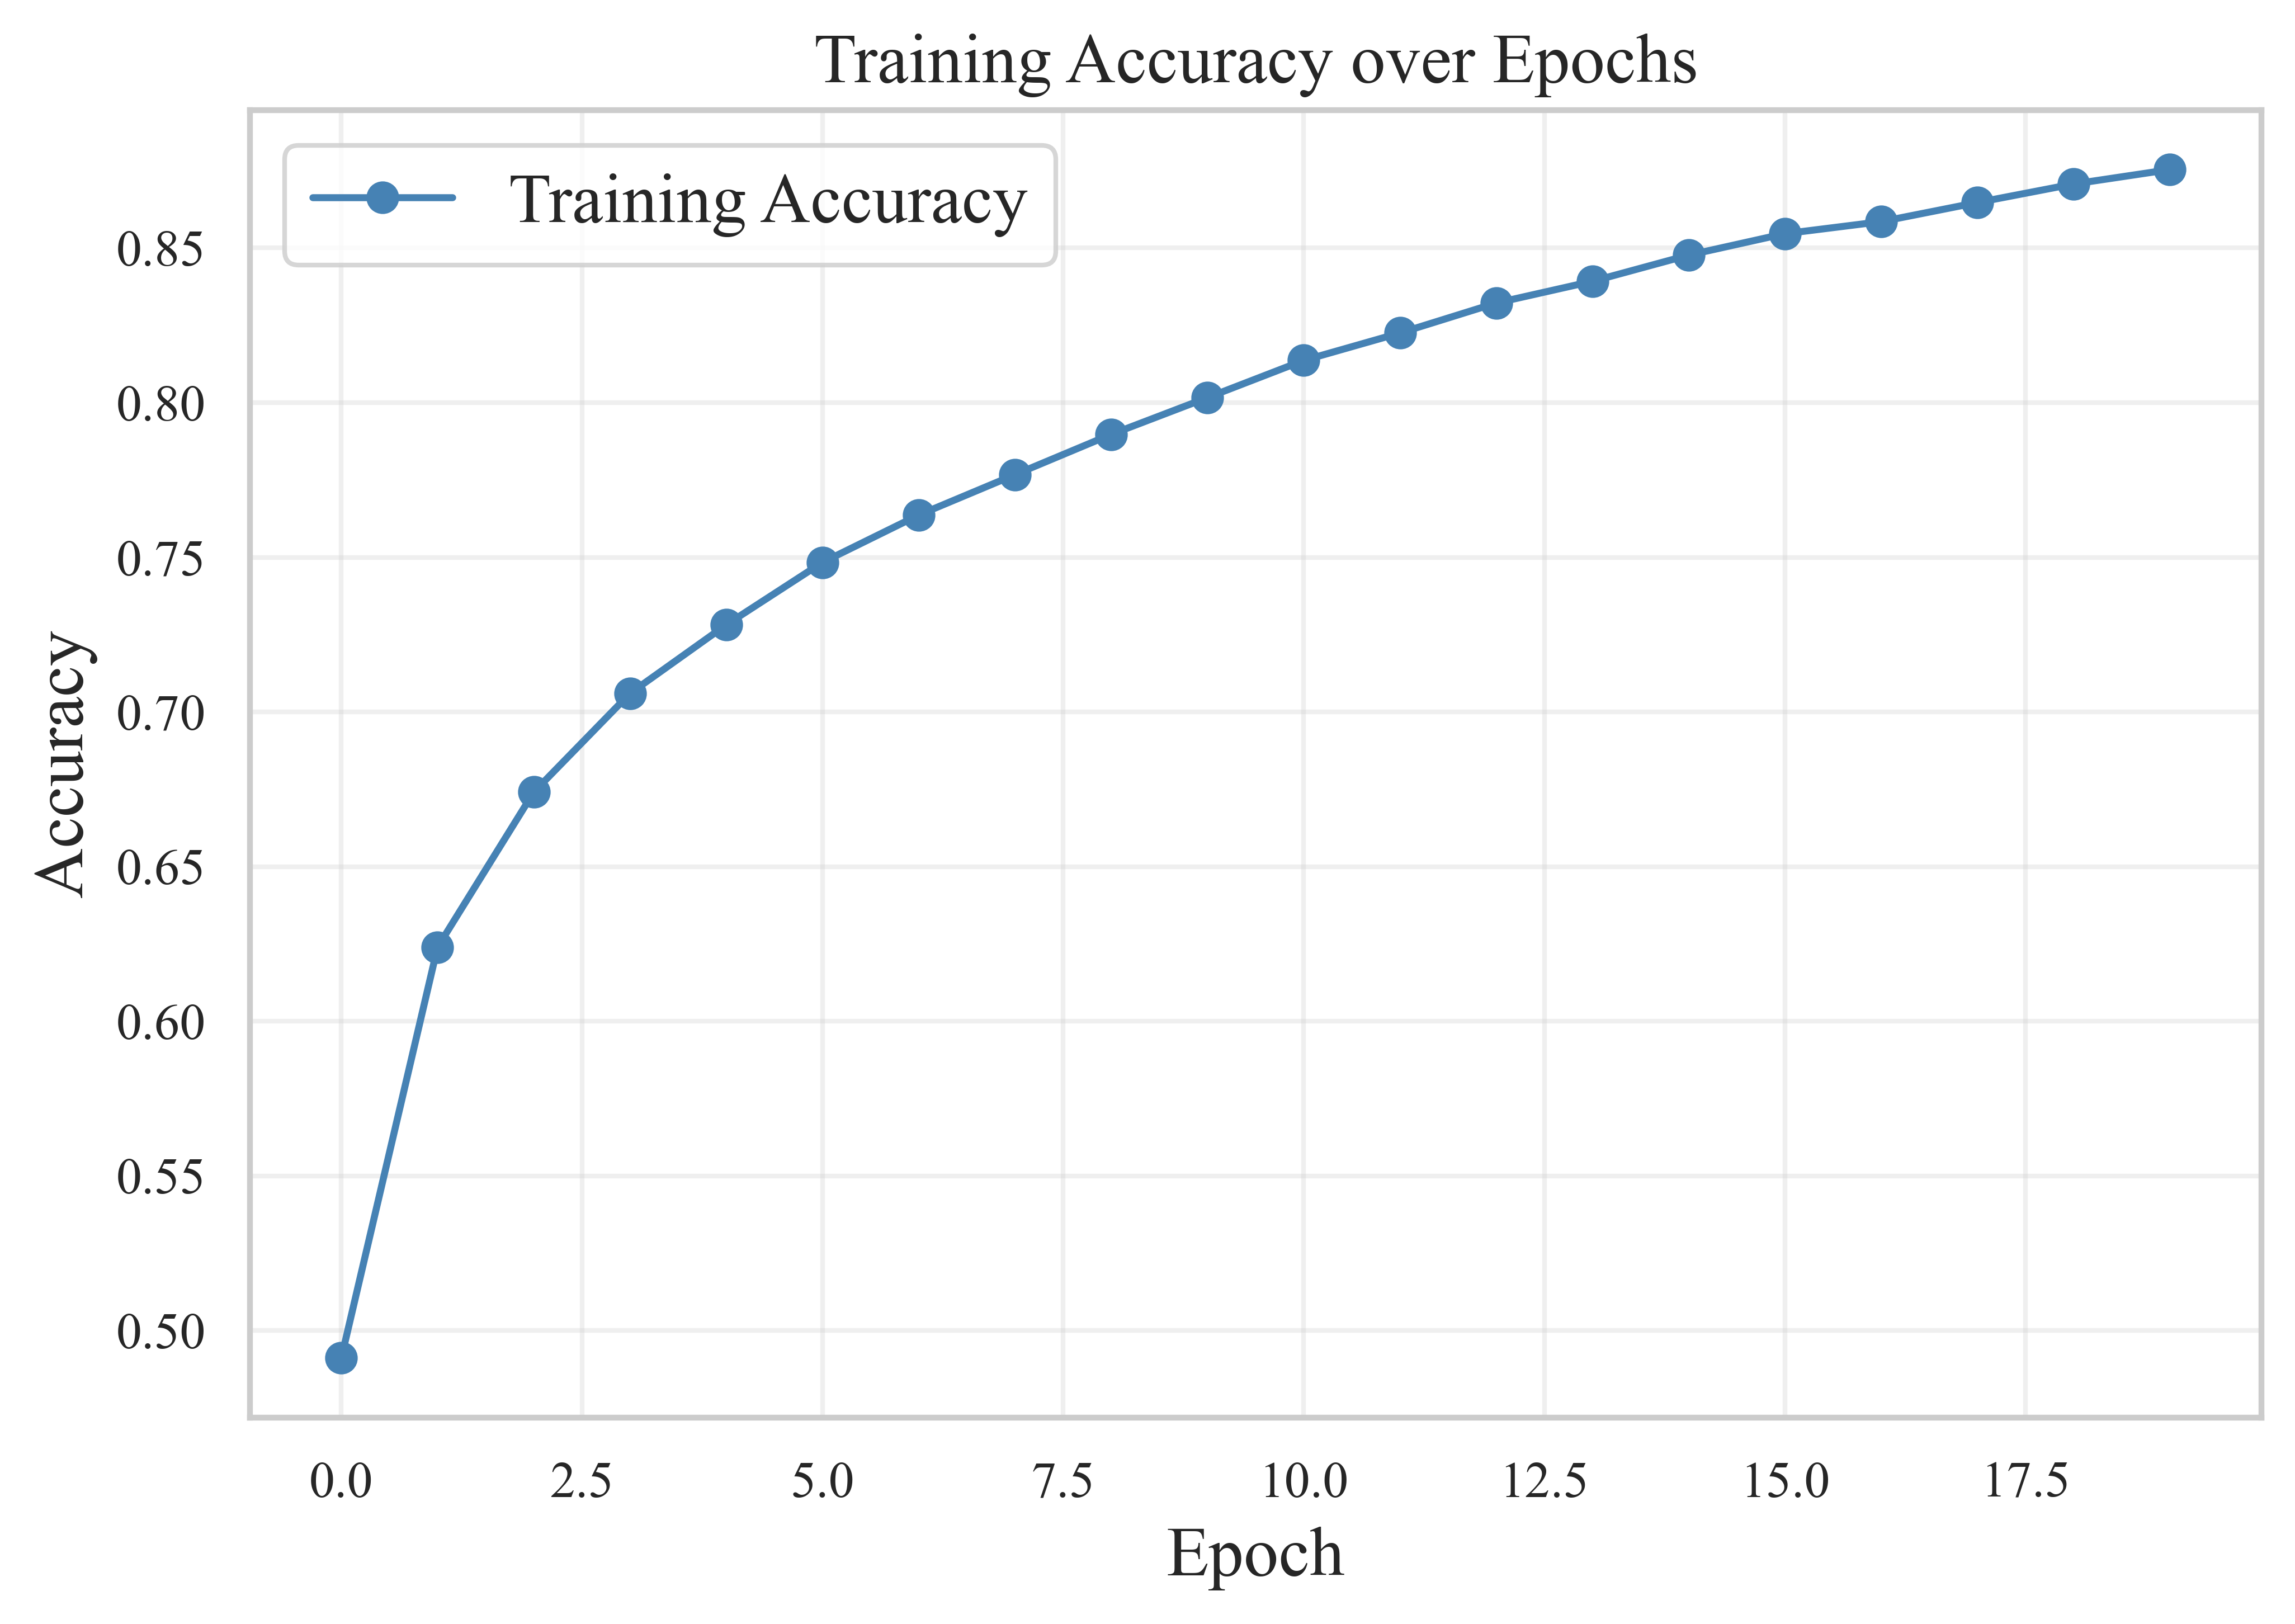

In [33]:
fig_ta = plt.figure(figsize=(7, 5))
ta_axis = plt.gca()
ta_axis.plot(baseline_history.history['accuracy'], marker='o', color='steelblue', label='Training Accuracy')
ta_axis.set_title('Training Accuracy over Epochs', **title_style)
ta_axis.set_xlabel('Epoch', **label_style)
ta_axis.set_ylabel('Accuracy', **label_style)
ta_legend = ta_axis.legend(prop=legend_style)
format_axis_ticks(ta_axis)
format_legend_text(ta_legend)
ta_axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_accuracy.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Training accuracy should climb steadily across the 20 epochs; since this architecture has no dropout or batch normalization (unlike the bigger model in Section 6), it's more prone to overfitting, so watch whether this keeps climbing well past where validation accuracy plateaus.

### 20.2 Validation Accuracy

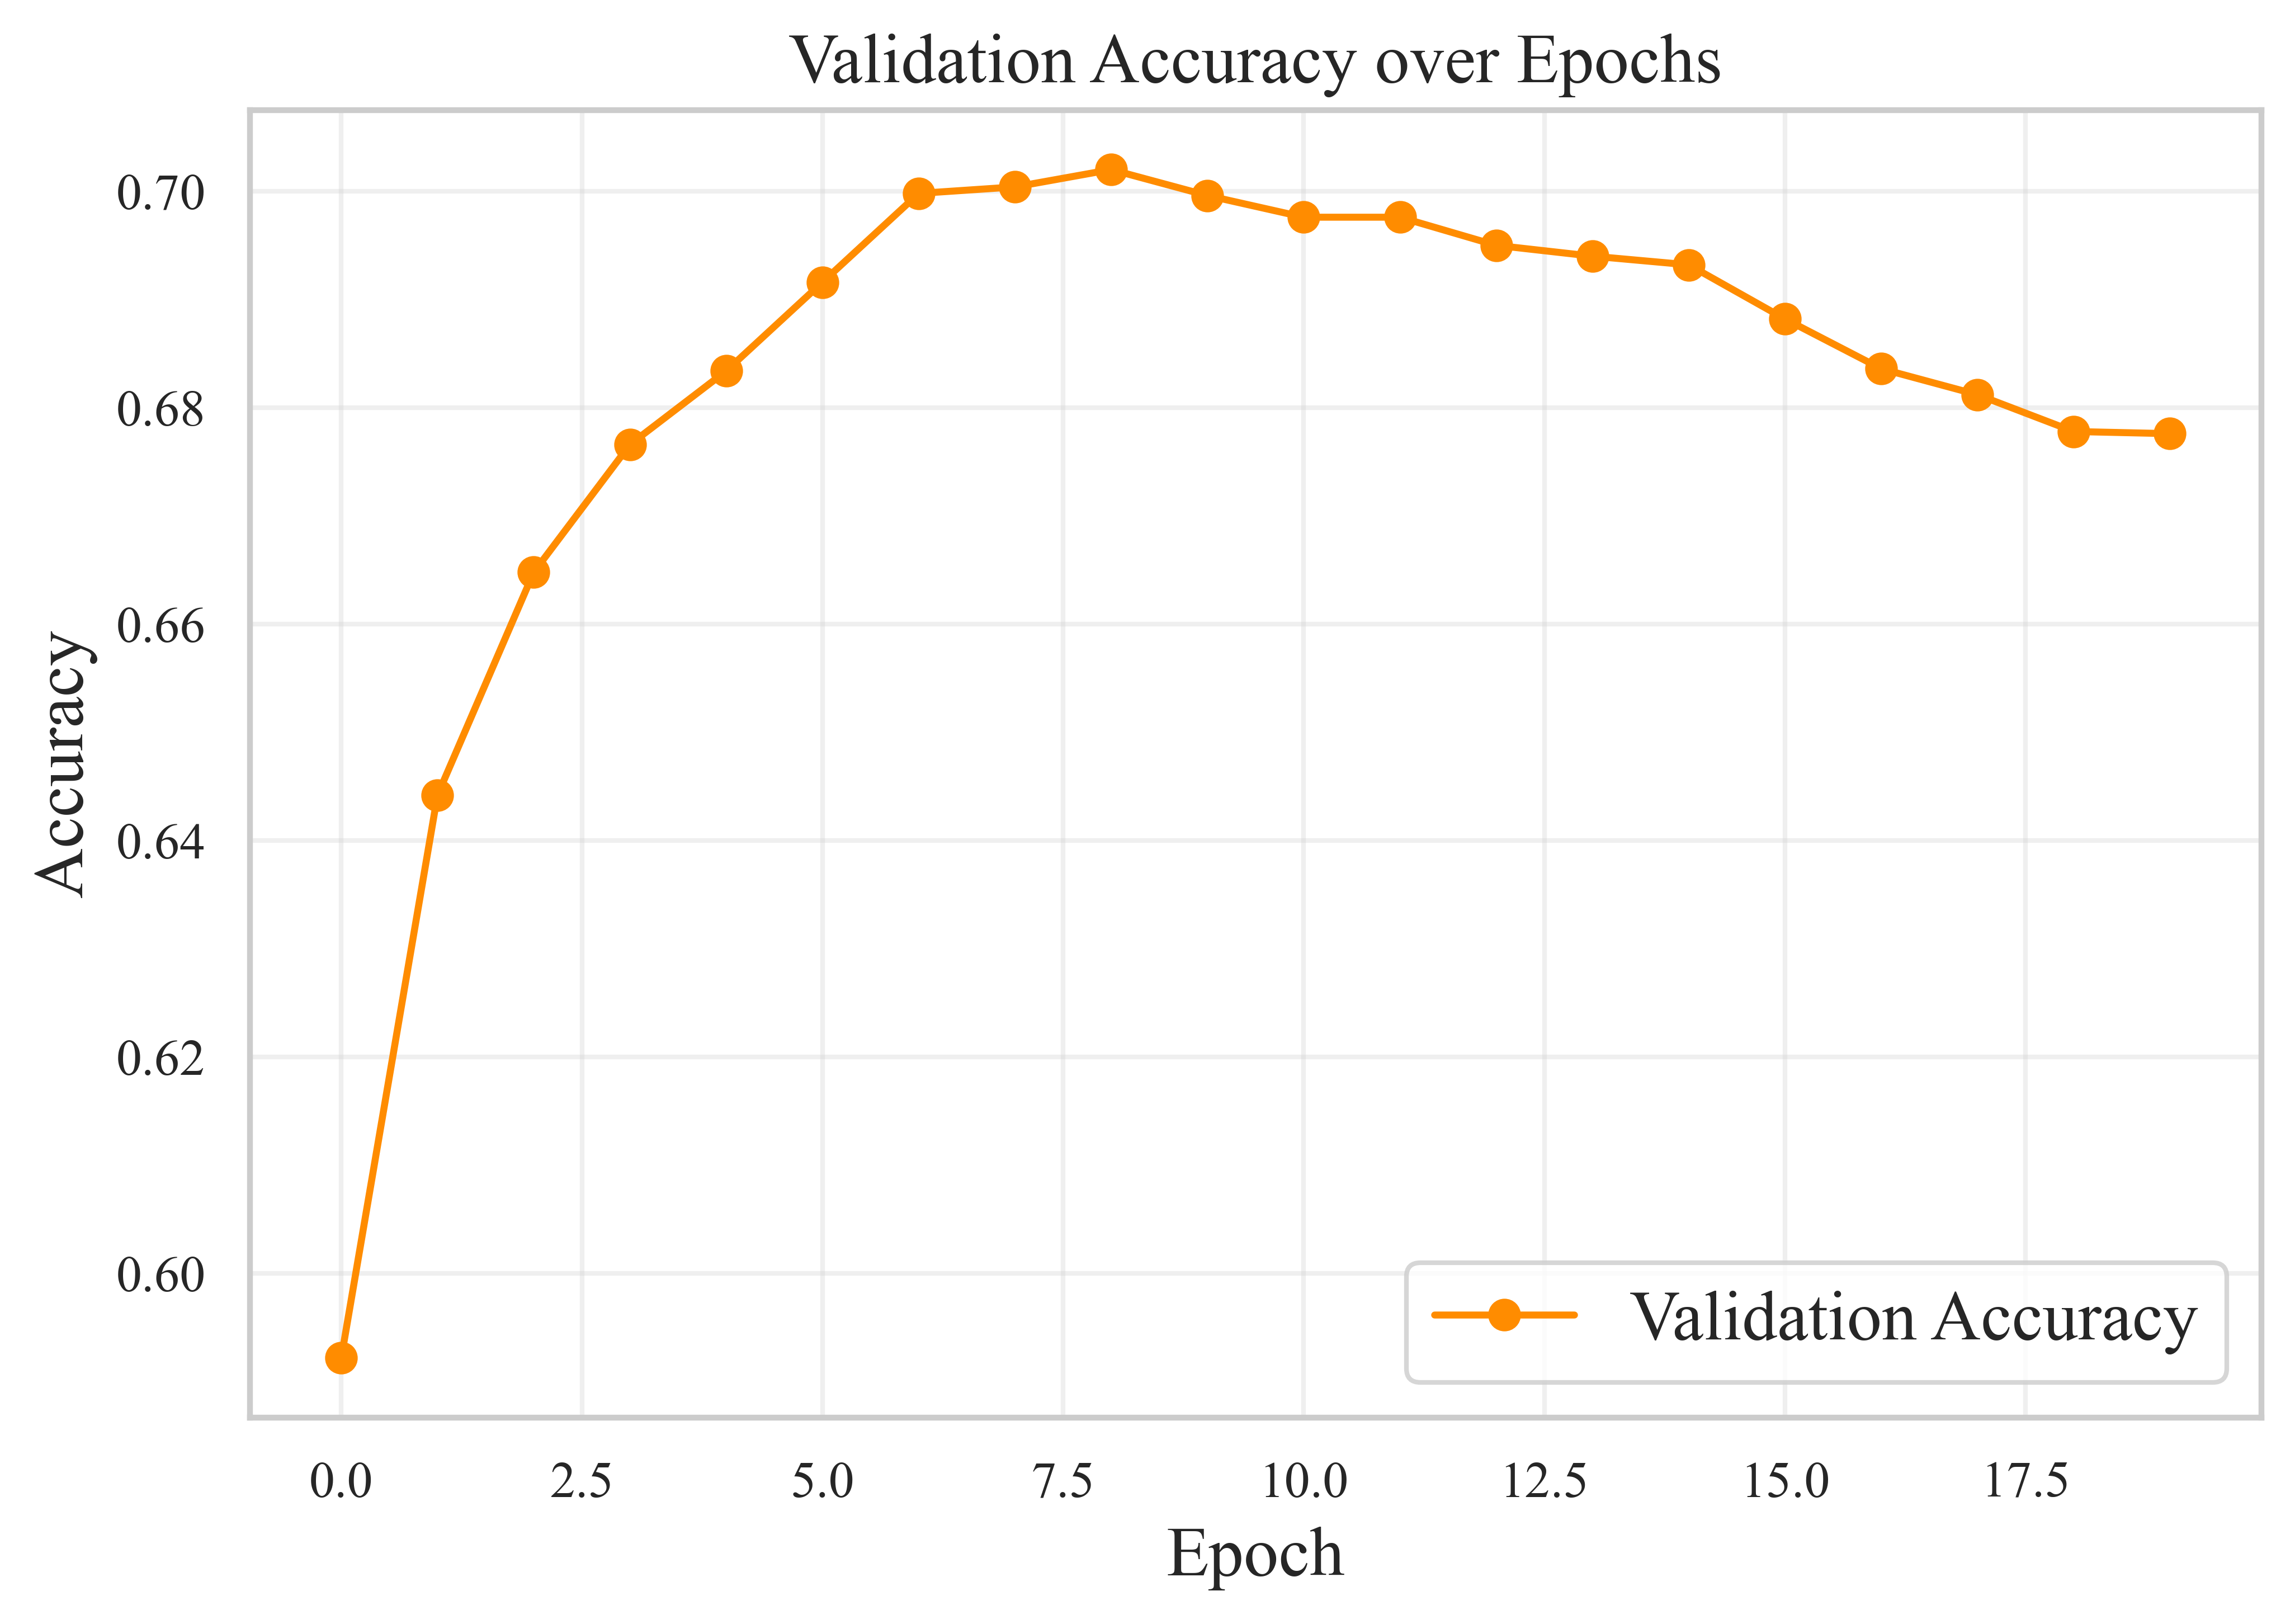

In [34]:
fig_va = plt.figure(figsize=(7, 5))
va_axis = plt.gca()
va_axis.plot(baseline_history.history['val_accuracy'], marker='o', color='darkorange', label='Validation Accuracy')
va_axis.set_title('Validation Accuracy over Epochs', **title_style)
va_axis.set_xlabel('Epoch', **label_style)
va_axis.set_ylabel('Accuracy', **label_style)
va_legend = va_axis.legend(prop=legend_style)
format_axis_ticks(va_axis)
format_legend_text(va_legend)
va_axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("validation_accuracy.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** If validation accuracy plateaus or dips while training accuracy keeps rising, that gap is this simpler, unregularized architecture overfitting -- a useful direct contrast against the bigger, dropout-regularized model in Section 6.

### 20.3 Training Loss

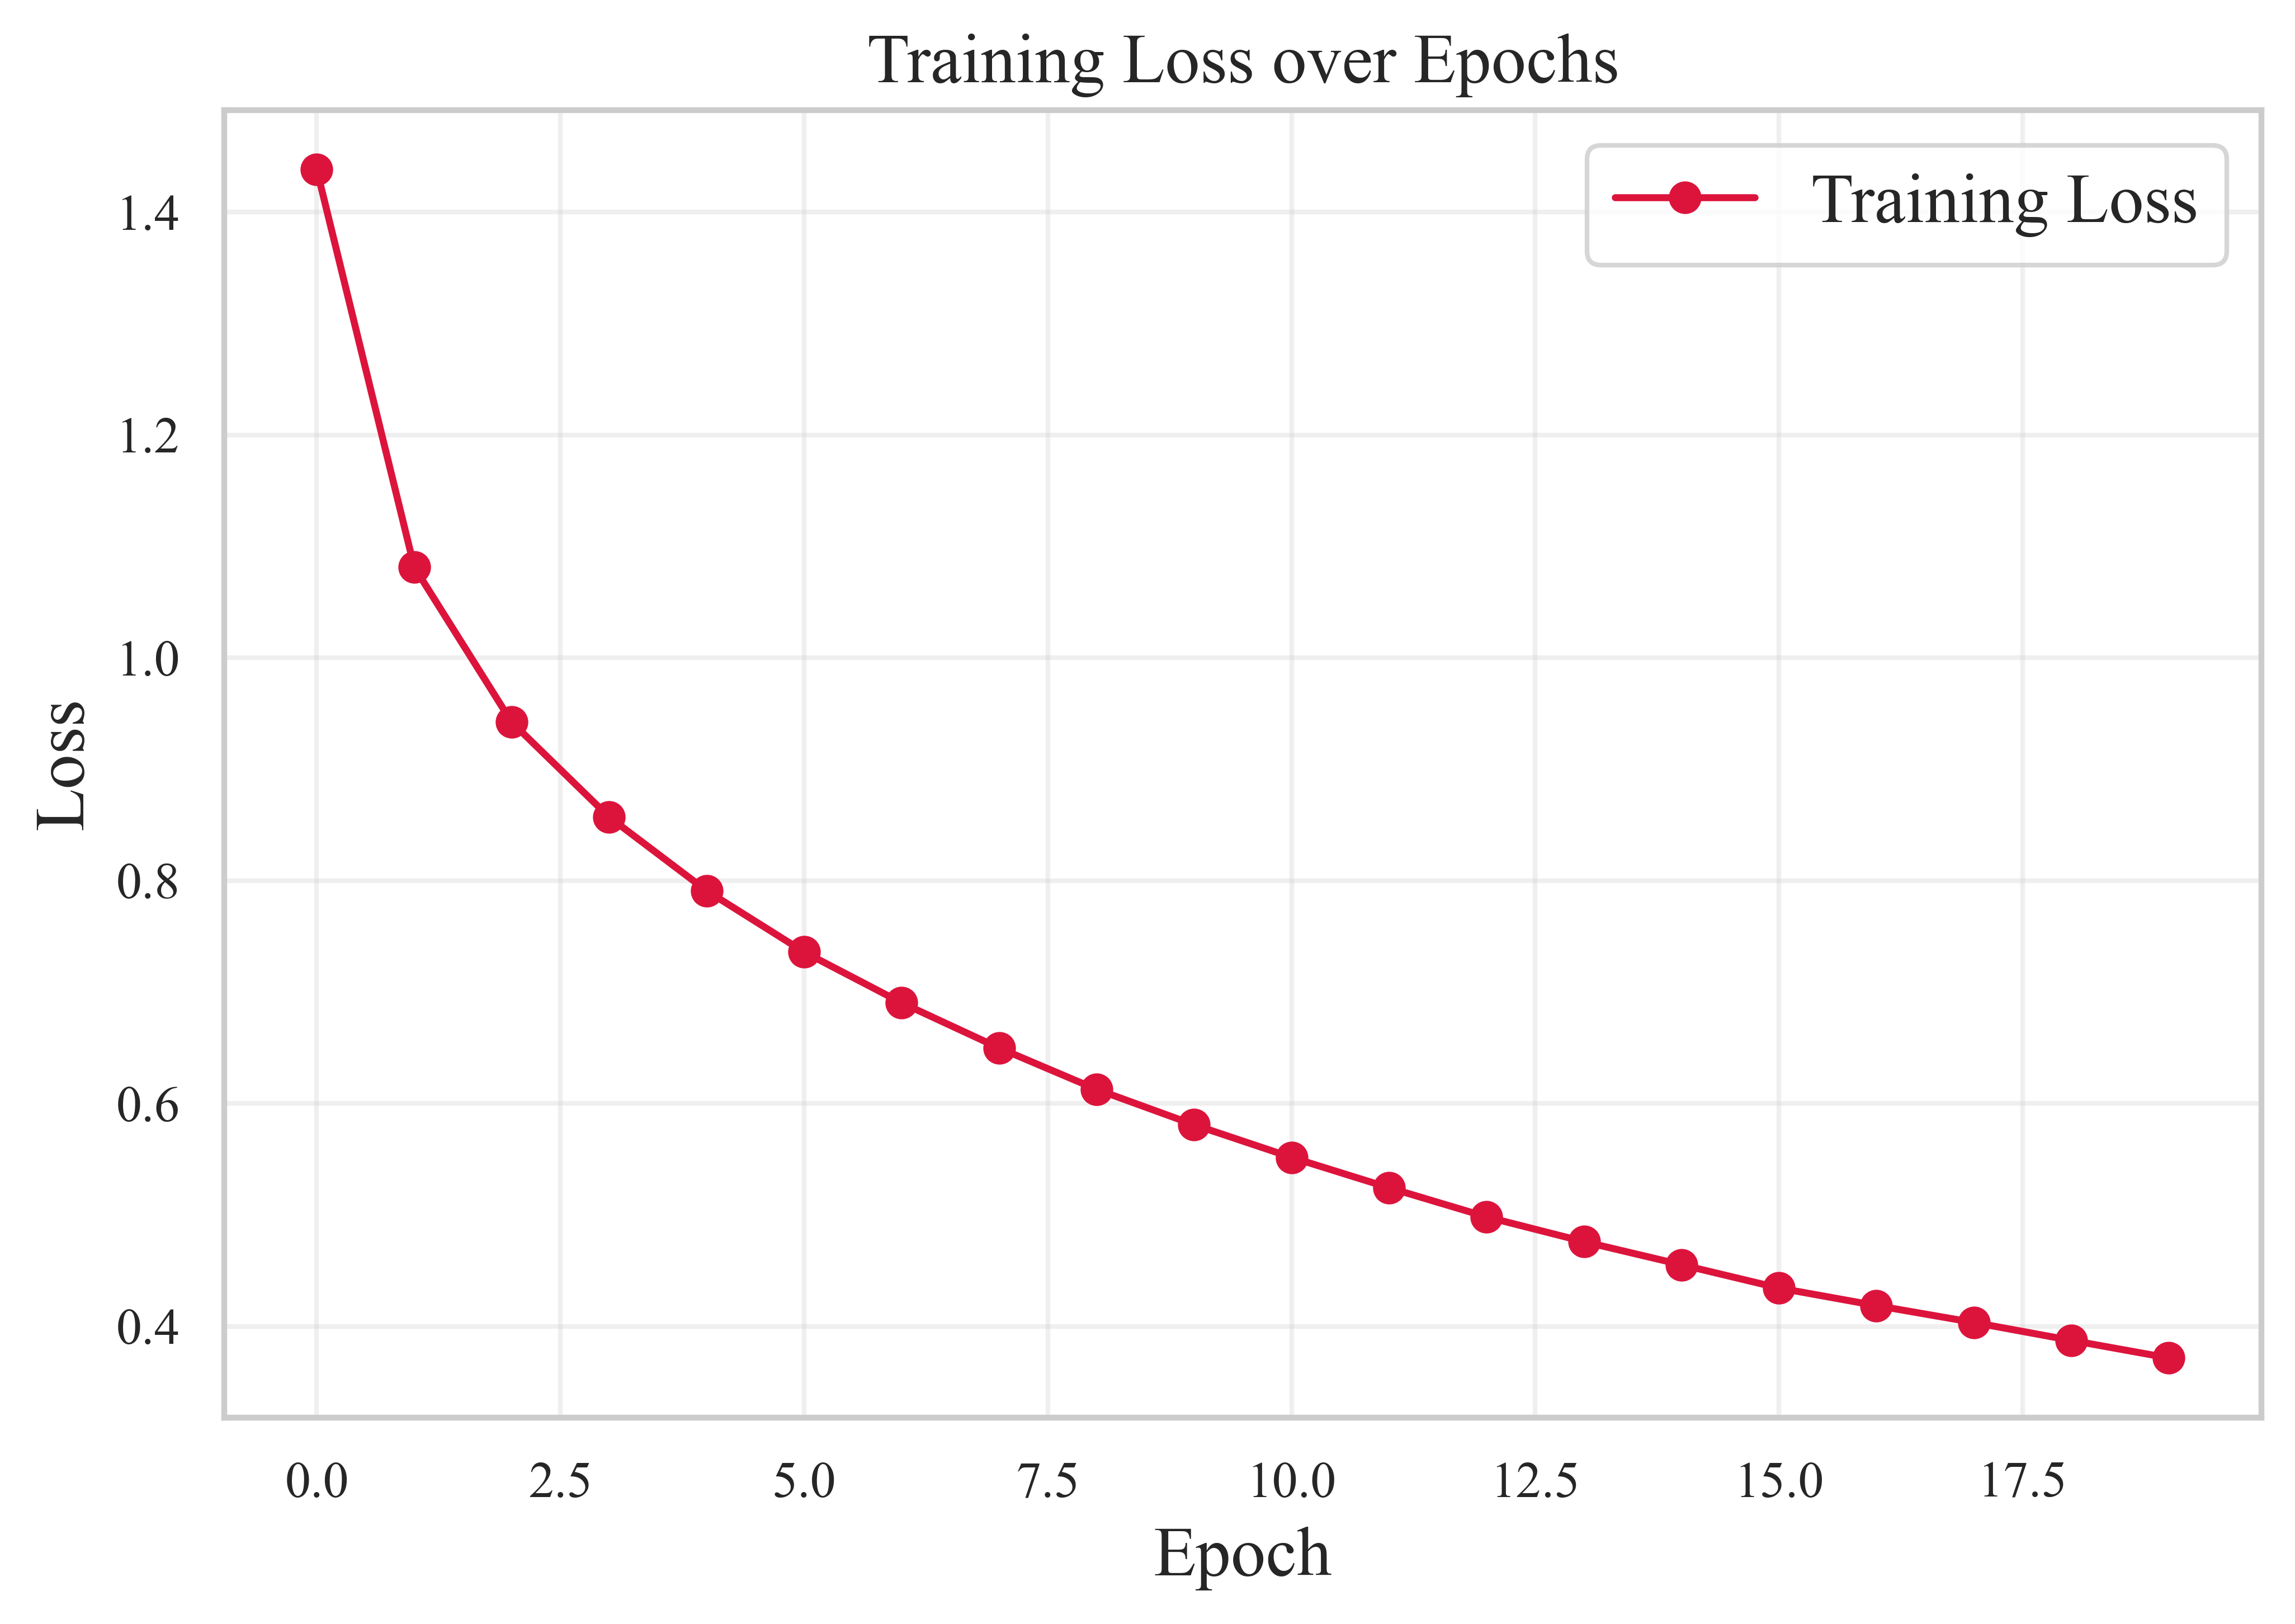

In [35]:
fig_tl = plt.figure(figsize=(7, 5))
tl_axis = plt.gca()
tl_axis.plot(baseline_history.history['loss'], marker='o', color='crimson', label='Training Loss')
tl_axis.set_title('Training Loss over Epochs', **title_style)
tl_axis.set_xlabel('Epoch', **label_style)
tl_axis.set_ylabel('Loss', **label_style)
tl_legend = tl_axis.legend(prop=legend_style)
format_axis_ticks(tl_axis)
format_legend_text(tl_legend)
tl_axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Training loss should fall consistently across all 20 epochs -- a smooth decline here confirms the optimizer is making steady progress even without the batch normalization the bigger model relies on.

### 20.4 Validation Loss

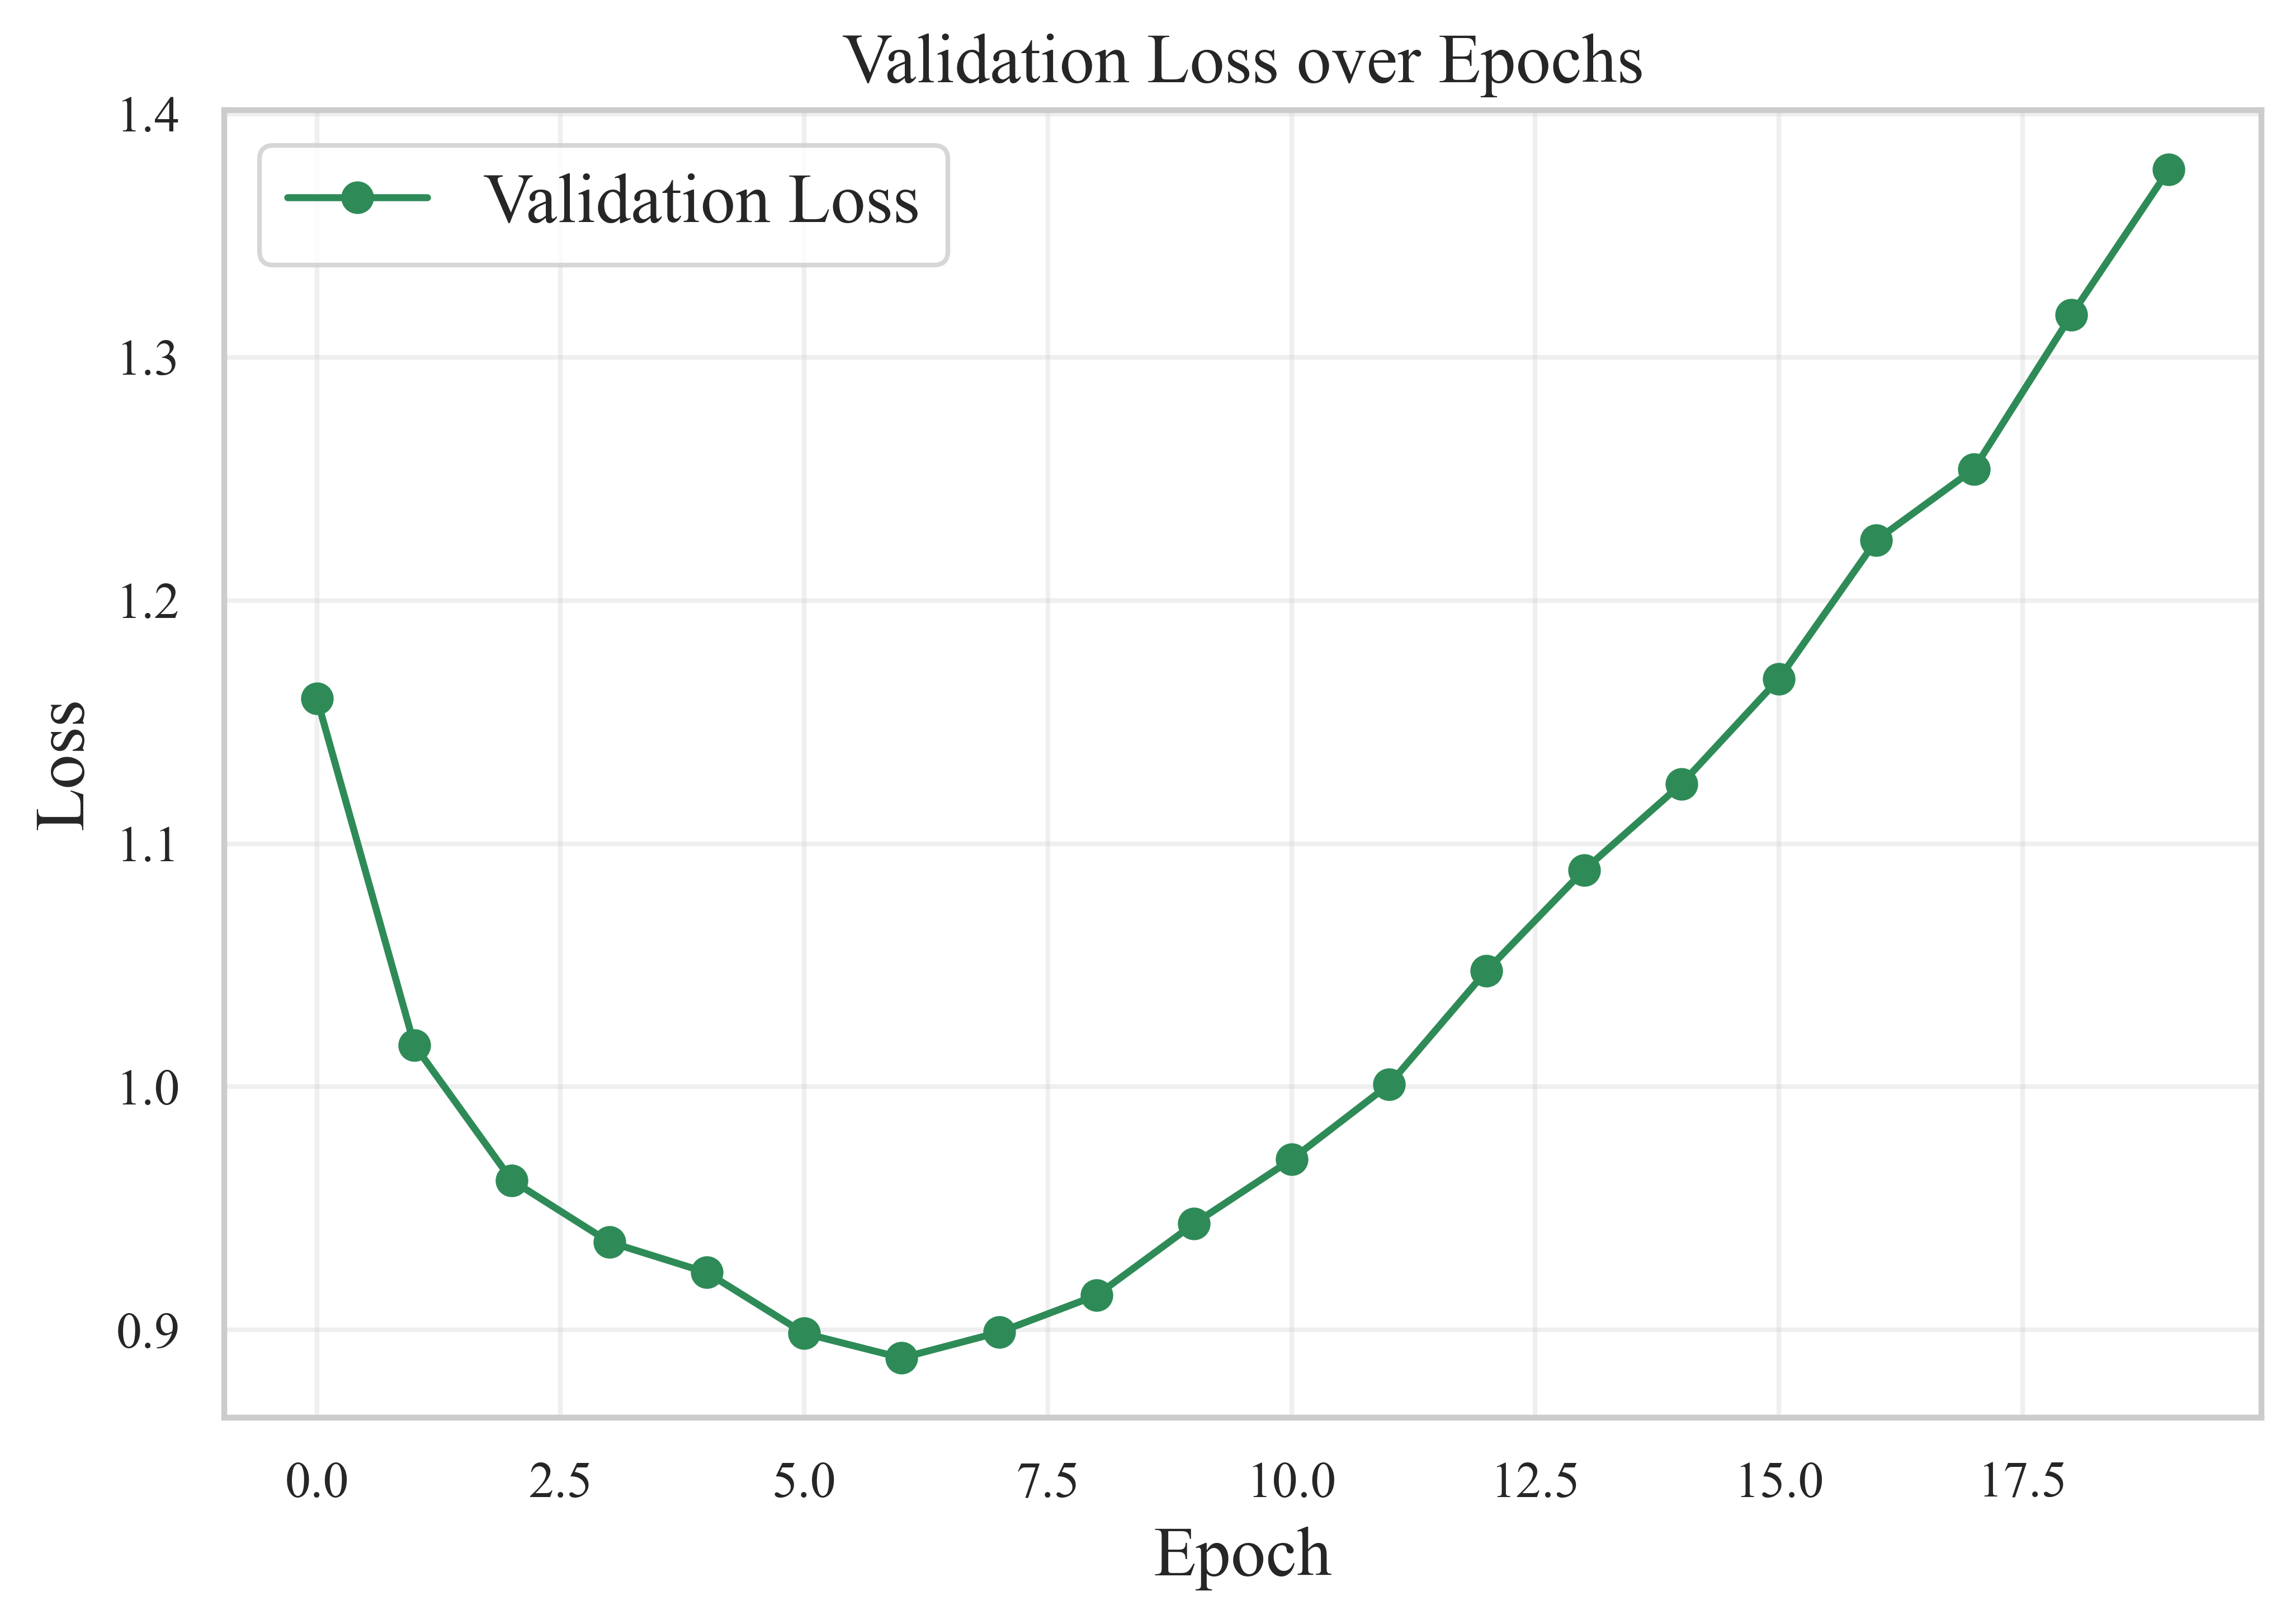

In [36]:
fig_vl = plt.figure(figsize=(7, 5))
vl_axis = plt.gca()
vl_axis.plot(baseline_history.history['val_loss'], marker='o', color='seagreen', label='Validation Loss')
vl_axis.set_title('Validation Loss over Epochs', **title_style)
vl_axis.set_xlabel('Epoch', **label_style)
vl_axis.set_ylabel('Loss', **label_style)
vl_legend = vl_axis.legend(prop=legend_style)
format_axis_ticks(vl_axis)
format_legend_text(vl_legend)
vl_axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("validation_loss.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Inference:** Without early stopping (the manual's Task 6 doesn't specify any), validation loss may start climbing back up in the later epochs even as training loss keeps falling -- exactly the overfitting signature this simpler, unregularized architecture is prone to, and precisely what `EarlyStopping`/`Dropout`/`BatchNormalization` in Section 6's model were added to prevent.

## 21. Additional Exercises

### 21.1 Exercise 1 — Output Size Calculation (64×64 image, 5×5 kernel, stride 2, padding 2)

In [37]:
N, F, P, S = 64, 5, 2, 2
output_size = (N - F + 2 * P) // S + 1
print(f"Output size = (N - F + 2P) / S + 1 = ({N} - {F} + 2*{P}) / {S} + 1 = {output_size}")
print(f"\nResult: a {N}x{N} input with a {F}x{F} kernel, stride {S}, padding {P} "
      f"produces a {output_size}x{output_size} output feature map.")


Output size = (N - F + 2P) / S + 1 = (64 - 5 + 2*2) / 2 + 1 = 32

Result: a 64x64 input with a 5x5 kernel, stride 2, padding 2 produces a 32x32 output feature map.


### 21.2 Exercise 2 — Trainable Parameters (64 filters, 3×3 kernel, RGB input)

In [38]:
filters, kernel_h, kernel_w, in_channels = 64, 3, 3, 3
params = (kernel_h * kernel_w * in_channels + 1) * filters
print(f"Parameters = (kernel_h * kernel_w * in_channels + 1) * filters")
print(f"           = ({kernel_h} * {kernel_w} * {in_channels} + 1) * {filters}")
print(f"           = {params:,}")


Parameters = (kernel_h * kernel_w * in_channels + 1) * filters
           = (3 * 3 * 3 + 1) * 64
           = 1,792


### 21.3 Exercise 3 — ReLU vs. Sigmoid Activation Comparison

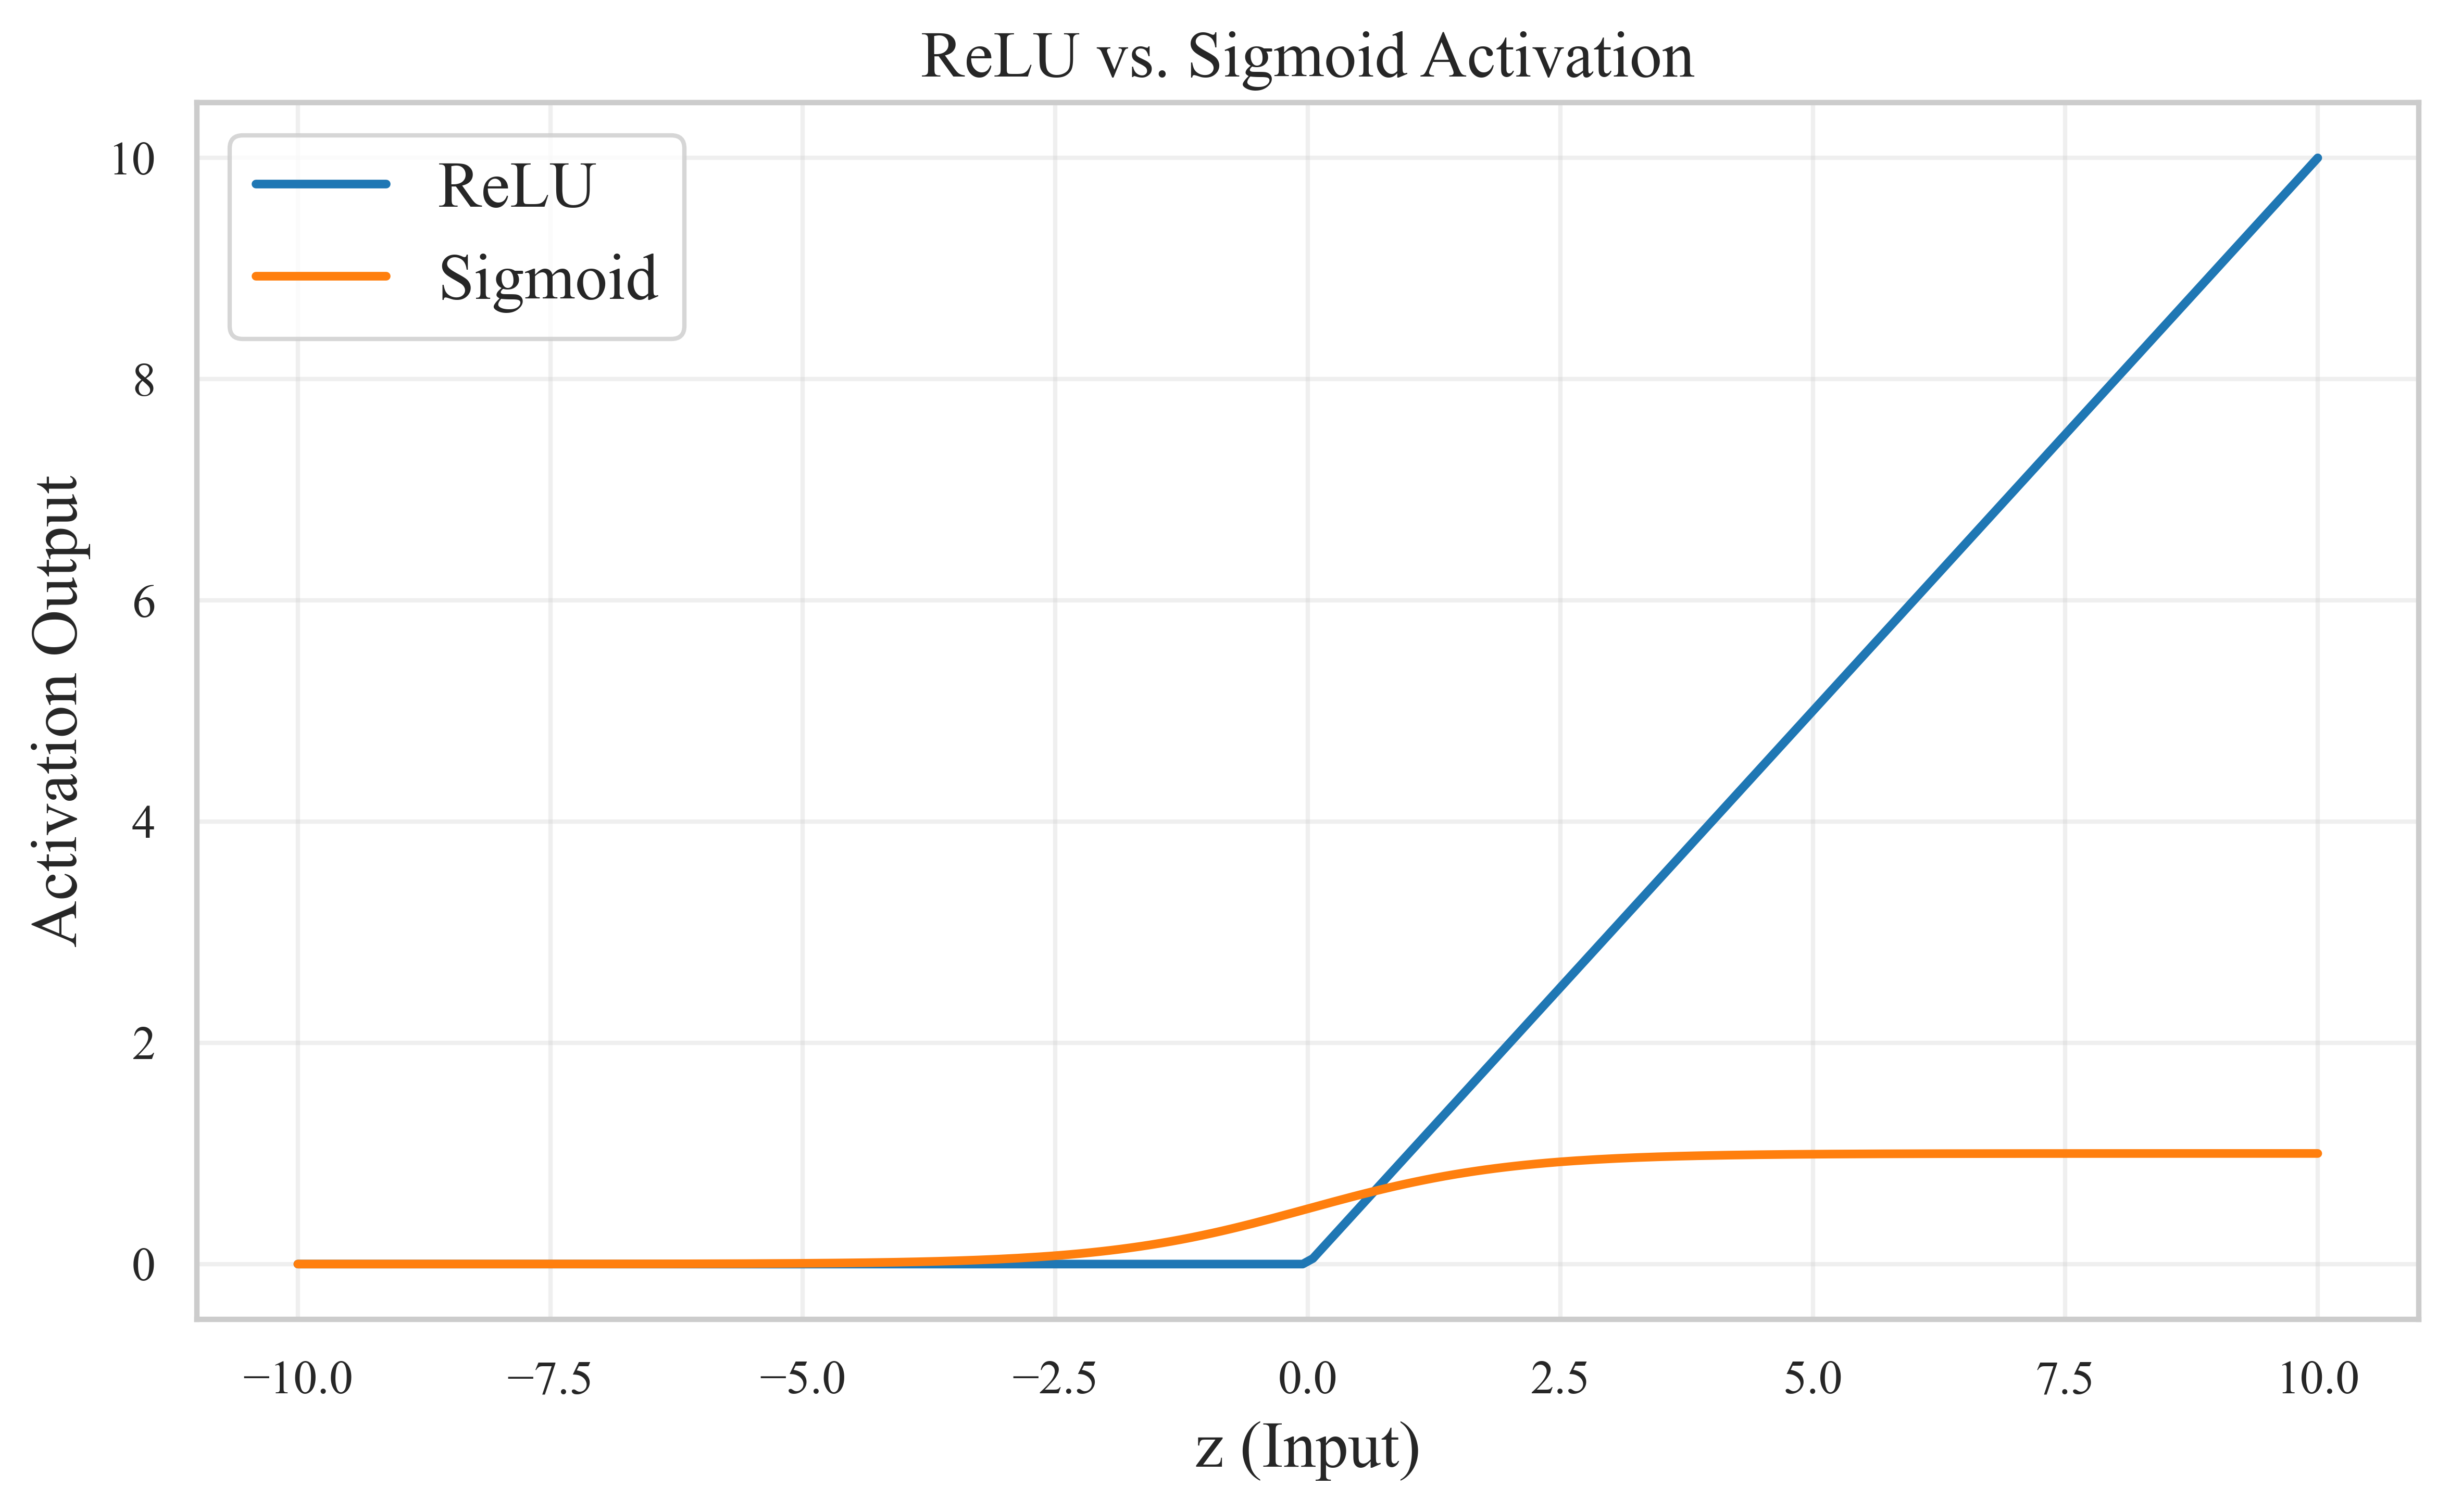

In [39]:
z = np.linspace(-10, 10, 200)
relu_output = np.maximum(0, z)
sigmoid_output = 1 / (1 + np.exp(-z))

act_fig = plt.figure(figsize=(8, 5))
act_axis = plt.gca()
act_axis.plot(z, relu_output, label='ReLU', linewidth=2)
act_axis.plot(z, sigmoid_output, label='Sigmoid', linewidth=2)
act_axis.set_title('ReLU vs. Sigmoid Activation', **title_style)
act_axis.set_xlabel('z (Input)', **label_style)
act_axis.set_ylabel('Activation Output', **label_style)
act_legend = act_axis.legend(prop=legend_style)
format_axis_ticks(act_axis)
format_legend_text(act_legend)
act_axis.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("relu_vs_sigmoid.eps", format='eps', dpi=600, bbox_inches='tight')
plt.show()


**Comparison:** ReLU is zero for any negative input and passes positive values through unchanged, which keeps gradients from vanishing for active neurons and is cheap to compute -- this is why every hidden layer in this notebook's CNNs uses ReLU. Sigmoid squashes everything into $(0,1)$, but its gradient becomes extremely small for large positive or negative inputs (the "vanishing gradient" problem), which makes it a poor choice for hidden layers in deep networks -- it's mainly reserved for binary classification output layers instead.

### 21.4 Exercise 4 — Replace Max Pooling with Average Pooling

*Already covered directly by Section 12 ("Comparing Pooling Strategies: Max Pooling vs. Average Pooling"), which trains and compares both on the full pipeline, and by Section 18 above, which compares their output shapes. No additional cell needed here -- see those two sections for the full comparison and results.*

### 21.5 Exercise 5 — Effect of Increasing Filters (16 → 64)

In [40]:
import time as _time

def build_filter_test_cnn(num_filters):
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(num_filters, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(num_filters * 2, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    return keras.Model(inputs, outputs)

filter_results = {}

for n_filters in [16, 64]:
    print(f"\n--- Training with {n_filters} filters in the first conv layer ---")
    m = build_filter_test_cnn(n_filters)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    start = _time.time()
    h = m.fit(x_train_final[:subset], y_train_final[:subset],
              validation_data=(x_val, y_val_cat), epochs=8, batch_size=64, verbose=0)
    elapsed = _time.time() - start

    test_loss, test_acc = m.evaluate(x_test, y_test_cat, verbose=0)
    filter_results[n_filters] = {'history': h, 'test_acc': test_acc, 'time': elapsed, 'params': m.count_params()}
    print(f"{n_filters} filters -> Test Accuracy: {test_acc:.4f}, "
          f"Training Time: {elapsed:.1f}s, Parameters: {m.count_params():,}")

print("\nSummary:")
for n_filters in filter_results:
    r = filter_results[n_filters]
    print(f"Filters={n_filters:3d} -> Test Acc: {r['test_acc']:.4f} | "
          f"Time: {r['time']:.1f}s | Params: {r['params']:,}")



--- Training with 16 filters in the first conv layer ---
16 filters -> Test Accuracy: 0.5401, Training Time: 11.9s, Parameters: 25,578

--- Training with 64 filters in the first conv layer ---
64 filters -> Test Accuracy: 0.5929, Training Time: 15.0s, Parameters: 157,578

Summary:
Filters= 16 -> Test Acc: 0.5401 | Time: 11.9s | Params: 25,578
Filters= 64 -> Test Acc: 0.5929 | Time: 15.0s | Params: 157,578


**Inference:** More filters give the network a richer set of feature detectors to work with, which usually helps accuracy -- but that comes at a direct cost in both parameter count and training time, since every additional filter adds its own full set of weights and a full extra feature map to compute at every position. Whether the accuracy gain is worth the extra time depends entirely on how much budget there is for training and inference.

### 22. Re-Download All EPS Plots (Including the New Ones)

The original ZIP/download cell (Section 15) runs before all the new sections added above, so it only captured the plots that existed at that point. This cell repeats the same zip-and-download step, now that the new plots from Sections 16-21 exist too, so the final download actually includes everything -- the original 13 plots plus the new `kernel_size_comparison.eps`, `confusion_matrix_manual_spec.eps`, `training_accuracy.eps`, `validation_accuracy.eps`, `training_loss.eps`, `validation_loss.eps`, and `relu_vs_sigmoid.eps`.


In [41]:
import glob
import zipfile

eps_files = glob.glob("*.eps")
print(f"Found {len(eps_files)} EPS files:")
for eps_file in sorted(eps_files):
    print(" -", eps_file)

with zipfile.ZipFile("cnn_cifar10_eps_plots_complete.zip", "w") as zip_file:
    for eps_file in eps_files:
        zip_file.write(eps_file)

print("\nZIP archive created: cnn_cifar10_eps_plots_complete.zip")

try:
    from google.colab import files
    files.download("cnn_cifar10_eps_plots_complete.zip")
except ImportError:
    print("Not running in Google Colab — the ZIP file is saved in the current working directory. "
          "Download it manually from the file browser (left sidebar in Jupyter) if needed.")


Found 20 EPS files:
 - batch_size_comparison.eps
 - class_distribution.eps
 - confusion_matrix.eps
 - confusion_matrix_manual_spec.eps
 - feature_map_input_image.eps
 - feature_maps_conv1.eps
 - feature_maps_conv2.eps
 - feature_maps_conv3.eps
 - feature_maps_conv4.eps
 - feature_maps_conv5.eps
 - kernel_size_comparison.eps
 - pooling_comparison.eps
 - relu_vs_sigmoid.eps
 - sample_images.eps
 - sample_predictions.eps
 - training_accuracy.eps
 - training_curves.eps
 - training_loss.eps
 - validation_accuracy.eps
 - validation_loss.eps

ZIP archive created: cnn_cifar10_eps_plots_complete.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>